<a href="https://colab.research.google.com/github/nehin17/network-attack-forecasting/blob/main/Network_Attack_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# STEP 1: CONNECT GOOGLE DRIVE TO GOOGLE COLAB
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# STEP 2: CHECK FILES IN GOOGLE DRIVE
# ============================================================

import os

DRIVE_PATH = "/content/drive/MyDrive"

print("Files/folders in My Drive:\n")

for item in os.listdir(DRIVE_PATH):
    print(item)

Files/folders in My Drive:

Untitled document.gdoc
neha resume photo.gdoc
Colab Notebooks
cicids2017_cleaned_chronological.csv


In [4]:
# ============================================================
# STEP 3: FIND THE CICIDS2017 CSV AUTOMATICALLY
# ============================================================

import os

FILE_NAME = "cicids2017_cleaned_chronological.csv"

found_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if FILE_NAME in files:
        found_path = os.path.join(root, FILE_NAME)
        break

if found_path:
    print("Dataset found!")
    print("Path:", found_path)
else:
    print("Dataset NOT found.")

Dataset found!
Path: /content/drive/MyDrive/cicids2017_cleaned_chronological.csv


In [5]:
# ============================================================
# STEP 4: SAVE DATASET LOCATION
# ============================================================

DATA_PATH = found_path

print("Dataset location:")
print(DATA_PATH)

Dataset location:
/content/drive/MyDrive/cicids2017_cleaned_chronological.csv


In [6]:
# ============================================================
# STEP 5: VERIFY THE FILE EXISTS
# ============================================================

import os

if os.path.exists(DATA_PATH):
    print("✓ Dataset exists.")

    size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)
    print(f"File size: {size_mb:.2f} MB")
else:
    print("✗ Dataset could not be found.")

✓ Dataset exists.
File size: 281.22 MB


In [7]:
# ============================================================
# STEP 6: IMPORT DATA ANALYSIS LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Makes pandas display all columns instead of hiding some
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
# ============================================================
# STEP 7: PREVIEW THE DATASET BEFORE FULL LOADING
# ============================================================

preview = pd.read_csv(
    DATA_PATH,
    nrows=5
)

print("Dataset preview:")

display(preview)

Dataset preview:


,Timestamp,Source_IP,Destination_IP,Source_Port,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Bwd_Packets,Total_Len_Fwd_Packets,Total_Len_Bwd_Packets,Fwd_IAT_Mean,Bwd_IAT_Mean,Protocol,Label
0,2017-03-07 01:00:01,192.168.10.3,192.168.10.1,61098.0,53.0,86739.0,1.0,1.0,51.0,67.0,0.000000e+00,0.000000e+00,17,0
1,2017-03-07 01:00:01,192.168.10.25,23.194.182.12,59385.0,443.0,4.0,2.0,0.0,12.0,0.0,4.000000e+00,0.000000e+00,6,0
2,2017-03-07 01:00:01,8.6.0.1,8.0.6.4,0.0,0.0,118699862.0,76.0,0.0,0.0,0.0,1.582665e+06,0.000000e+00,0,0
3,2017-03-07 01:00:01,23.194.182.12,192.168.10.25,443.0,59385.0,3.0,2.0,0.0,37.0,0.0,3.000000e+00,0.000000e+00,6,0
4,2017-03-07 01:00:01,192.168.10.25,192.168.10.3,51147.0,53.0,100934792.0,4.0,4.0,142.0,684.0,3.364485e+07,3.361587e+07,17,0


In [9]:
# ============================================================
# STEP 8: CHECK COLUMN NAMES
# ============================================================

print("Number of columns:", len(preview.columns))

print("\nColumn names:")

for i, column in enumerate(preview.columns, start=1):
    print(f"{i}. {column}")

Number of columns: 14

Column names:
1. Timestamp
2. Source_IP
3. Destination_IP
4. Source_Port
5. Destination_Port
6. Flow_Duration
7. Total_Fwd_Packets
8. Total_Bwd_Packets
9. Total_Len_Fwd_Packets
10. Total_Len_Bwd_Packets
11. Fwd_IAT_Mean
12. Bwd_IAT_Mean
13. Protocol
14. Label


In [10]:
# ============================================================
# STEP 9: LOAD THE COMPLETE CICIDS2017 DATASET
# ============================================================

print("Loading full dataset...")

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print("Dataset loaded successfully!")

print("\nDataset shape:")
print(df.shape)

Loading full dataset...
Dataset loaded successfully!

Dataset shape:
(2830743, 14)


In [11]:
# ============================================================
# STEP 10: DISPLAY FIRST 10 NETWORK FLOWS
# ============================================================

display(df.head(10))

,Timestamp,Source_IP,Destination_IP,Source_Port,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Bwd_Packets,Total_Len_Fwd_Packets,Total_Len_Bwd_Packets,Fwd_IAT_Mean,Bwd_IAT_Mean,Protocol,Label
0,2017-03-07 01:00:01,192.168.10.3,192.168.10.1,61098.0,53.0,86739.0,1.0,1.0,51.0,67.0,0.000000e+00,0.000000e+00,17,0
1,2017-03-07 01:00:01,192.168.10.25,23.194.182.12,59385.0,443.0,4.0,2.0,0.0,12.0,0.0,4.000000e+00,0.000000e+00,6,0
2,2017-03-07 01:00:01,8.6.0.1,8.0.6.4,0.0,0.0,118699862.0,76.0,0.0,0.0,0.0,1.582665e+06,0.000000e+00,0,0
3,2017-03-07 01:00:01,23.194.182.12,192.168.10.25,443.0,59385.0,3.0,2.0,0.0,37.0,0.0,3.000000e+00,0.000000e+00,6,0
4,2017-03-07 01:00:01,192.168.10.25,192.168.10.3,51147.0,53.0,100934792.0,4.0,4.0,142.0,684.0,3.364485e+07,3.361587e+07,17,0
5,2017-03-07 01:00:01,192.168.10.25,23.194.182.12,59385.0,443.0,83823.0,10.0,5.0,713.0,479.0,9.313667e+03,1.297500e+04,6,0
6,2017-03-07 01:00:02,54.164.44.237,192.168.10.25,443.0,59264.0,3.0,2.0,0.0,37.0,0.0,3.000000e+00,0.000000e+00,6,0
7,2017-03-07 01:00:02,192.168.10.25,54.164.44.237,59264.0,443.0,3.0,2.0,0.0,12.0,0.0,3.000000e+00,0.000000e+00,6,0
8,2017-03-07 01:00:03,192.168.10.25,54.164.44.237,59386.0,443.0,60154786.0,11.0,6.0,901.0,964.0,6.015479e+06,1.202082e+07,6,0
9,2017-03-07 01:00:03,192.168.10.3,192.168.10.1,60401.0,53.0,37801.0,1.0,1.0,92.0,124.0,0.000000e+00,0.000000e+00,17,0


In [12]:
# ============================================================
# STEP 11: DISPLAY LAST 10 NETWORK FLOWS
# ============================================================

display(df.tail(10))

,Timestamp,Source_IP,Destination_IP,Source_Port,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Bwd_Packets,Total_Len_Fwd_Packets,Total_Len_Bwd_Packets,Fwd_IAT_Mean,Bwd_IAT_Mean,Protocol,Label
2830733,2017-07-07 12:59:00,192.168.10.8,205.174.165.73,4998.0,8080.0,996593.0,3.0,3.0,0.0,18.0,498042.0000,497979.00000,6,1
2830734,2017-07-07 12:59:00,192.168.10.17,91.189.89.198,123.0,123.0,94362.0,1.0,1.0,48.0,48.0,0.0000,0.00000,17,0
2830735,2017-07-07 12:59:00,192.168.10.14,205.174.165.73,53231.0,8080.0,1030558.0,3.0,3.0,0.0,18.0,514912.0000,515030.00000,6,1
2830736,2017-07-07 12:59:00,192.168.10.5,205.174.165.73,52376.0,8080.0,1032755.0,3.0,3.0,0.0,18.0,516017.0000,516039.00000,6,1
2830737,2017-07-07 12:59:00,192.168.10.17,108.59.2.24,123.0,123.0,28500.0,1.0,1.0,48.0,48.0,0.0000,0.00000,17,0
2830738,2017-07-07 12:59:00,192.168.10.9,74.125.22.109,6491.0,465.0,1866345.0,16.0,23.0,1396.0,4574.0,121089.1333,82585.68182,6,0
2830739,2017-07-07 12:59:00,192.168.10.3,192.168.10.1,61188.0,53.0,60762.0,1.0,1.0,43.0,113.0,0.0000,0.00000,17,0
2830740,2017-07-07 12:59:00,192.168.10.9,192.168.10.3,63877.0,53.0,61321.0,2.0,2.0,64.0,204.0,3.0000,4.00000,17,0
2830741,2017-07-07 12:59:00,192.168.10.50,192.168.10.19,137.0,137.0,4.0,2.0,0.0,124.0,0.0,4.0000,0.00000,17,0
2830742,2017-07-07 12:59:00,192.168.10.17,198.206.133.14,123.0,123.0,37832.0,1.0,1.0,48.0,48.0,0.0000,0.00000,17,0


In [13]:
# ============================================================
# STEP 12: CHECK MEMORY USAGE
# ============================================================

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"DataFrame memory usage: {memory_mb:.2f} MB")

DataFrame memory usage: 752.15 MB


In [14]:
# ============================================================
# STEP 13: INSPECT COLUMN DATA TYPES
# ============================================================

print(df.dtypes)

Timestamp                 object
Source_IP                 object
Destination_IP            object
Source_Port              float64
Destination_Port         float64
Flow_Duration            float64
Total_Fwd_Packets        float64
Total_Bwd_Packets        float64
Total_Len_Fwd_Packets    float64
Total_Len_Bwd_Packets    float64
Fwd_IAT_Mean             float64
Bwd_IAT_Mean             float64
Protocol                   int64
Label                      int64
dtype: object


In [15]:
# ============================================================
# STEP 14: CONVERT TIMESTAMP FROM TEXT TO DATETIME
# ============================================================

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

print("Timestamp conversion complete.")

print("\nTimestamp data type:")
print(df["Timestamp"].dtype)

print("\nInvalid timestamps:")
print(df["Timestamp"].isna().sum())

Timestamp conversion complete.

Timestamp data type:
datetime64[ns]

Invalid timestamps:
0


In [16]:
# ============================================================
# STEP 15: VERIFY CHRONOLOGICAL ORDER
# ============================================================

is_sorted = df["Timestamp"].is_monotonic_increasing

print("Dataset already chronological:", is_sorted)

Dataset already chronological: True


In [17]:
# ============================================================
# STEP 16: CHECK DATASET TIME RANGE
# ============================================================

print("Earliest timestamp:")
print(df["Timestamp"].min())

print("\nLatest timestamp:")
print(df["Timestamp"].max())

Earliest timestamp:
2017-03-07 01:00:01

Latest timestamp:
2017-07-07 12:59:00


In [18]:
# ============================================================
# STEP 17: INSPECT NORMAL VS ATTACK DISTRIBUTION
# ============================================================

label_counts = df["Label"].value_counts().sort_index()

print("Label counts:")
print(label_counts)

print("\nLabel percentages:")
print(
    df["Label"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .round(2)
)

Label counts:
Label
0    2273097
1     557646
Name: count, dtype: int64

Label percentages:
Label
0    80.3
1    19.7
Name: proportion, dtype: float64


In [19]:
# ============================================================
# STEP 18: INSPECT TRAFFIC BY DATE
# ============================================================

df["Date"] = df["Timestamp"].dt.date

daily_total = df.groupby("Date").size()

print("Total network flows per date:")
print(daily_total)

Total network flows per date:
Date
2017-03-07    529918
2017-04-07    445909
2017-05-07    692703
2017-06-07    458968
2017-07-07    703245
dtype: int64


In [20]:
# ============================================================
# STEP 19: NORMAL VS ATTACK FLOWS PER DATE
# ============================================================

daily_labels = pd.crosstab(
    df["Date"],
    df["Label"]
)

print("Normal/Attack distribution per date:")

display(daily_labels)

Normal/Attack distribution per date:


Label,0,1
Date,,
2017-03-07,529918,0
2017-04-07,432074,13835
2017-05-07,440031,252672
2017-06-07,456752,2216
2017-07-07,414322,288923


In [21]:
# ============================================================
# STEP 20: CHECK NUMERIC FEATURES FOR NaN / INFINITY
# ============================================================

numeric_columns = [
    "Source_Port",
    "Destination_Port",
    "Flow_Duration",
    "Total_Fwd_Packets",
    "Total_Bwd_Packets",
    "Total_Len_Fwd_Packets",
    "Total_Len_Bwd_Packets",
    "Fwd_IAT_Mean",
    "Bwd_IAT_Mean",
    "Protocol",
    "Label"
]

print("Missing values:")

print(
    df[numeric_columns]
    .isna()
    .sum()
)

print("\nInfinite values:")

for column in numeric_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        inf_count = np.isinf(df[column]).sum()

        print(f"{column}: {inf_count}")

Missing values:
Source_Port              0
Destination_Port         0
Flow_Duration            0
Total_Fwd_Packets        0
Total_Bwd_Packets        0
Total_Len_Fwd_Packets    0
Total_Len_Bwd_Packets    0
Fwd_IAT_Mean             0
Bwd_IAT_Mean             0
Protocol                 0
Label                    0
dtype: int64

Infinite values:
Source_Port: 0
Destination_Port: 0
Flow_Duration: 0
Total_Fwd_Packets: 0
Total_Bwd_Packets: 0
Total_Len_Fwd_Packets: 0
Total_Len_Bwd_Packets: 0
Fwd_IAT_Mean: 0
Bwd_IAT_Mean: 0
Protocol: 0
Label: 0


In [22]:
# ============================================================
# STEP 21: CORRECT THE MISINTERPRETED CICIDS DATE
# ============================================================
#
# Current dates appear as:
# 2017-03-07, 2017-04-07, ..., 2017-07-07
#
# We preserve the time-of-day but map those five dates to
# July 3, July 4, ..., July 7.
# ============================================================

date_mapping = {
    pd.Timestamp("2017-03-07").date(): pd.Timestamp("2017-07-03"),
    pd.Timestamp("2017-04-07").date(): pd.Timestamp("2017-07-04"),
    pd.Timestamp("2017-05-07").date(): pd.Timestamp("2017-07-05"),
    pd.Timestamp("2017-06-07").date(): pd.Timestamp("2017-07-06"),
    pd.Timestamp("2017-07-07").date(): pd.Timestamp("2017-07-07"),
}

# Keep original timestamp for traceability
df["Original_Timestamp"] = df["Timestamp"]

def correct_cic_timestamp(ts):
    correct_date = date_mapping[ts.date()]

    return (
        correct_date
        + pd.Timedelta(hours=ts.hour)
        + pd.Timedelta(minutes=ts.minute)
        + pd.Timedelta(seconds=ts.second)
        + pd.Timedelta(microseconds=ts.microsecond)
    )

df["Timestamp"] = df["Timestamp"].apply(correct_cic_timestamp)

print("Corrected date distribution:")
print(df.groupby(df["Timestamp"].dt.date).size())

print("\nNew time range:")
print("Start:", df["Timestamp"].min())
print("End  :", df["Timestamp"].max())

print("\nStill chronological:",
      df["Timestamp"].is_monotonic_increasing)

Corrected date distribution:
Timestamp
2017-07-03    529918
2017-07-04    445909
2017-07-05    692703
2017-07-06    458968
2017-07-07    703245
dtype: int64

New time range:
Start: 2017-07-03 01:00:01
End  : 2017-07-07 12:59:00

Still chronological: True


In [23]:
# ============================================================
# STEP 22: CHECK RECORDING PERIOD FOR EACH DAY
# ============================================================
#
# This tells us the first and last network flow recorded
# on every collection day.
# ============================================================

daily_time_range = df.groupby(
    df["Timestamp"].dt.date
)["Timestamp"].agg(["min", "max", "count"])

display(daily_time_range)

,min,max,count
Timestamp,,,
2017-07-03,2017-07-03 01:00:01,2017-07-03 12:59:58,529918
2017-07-04,2017-07-04 01:00:00,2017-07-04 12:59:00,445909
2017-07-05,2017-07-05 01:00:00,2017-07-05 12:59:00,692703
2017-07-06,2017-07-06 01:00:00,2017-07-06 12:59:00,458968
2017-07-07,2017-07-07 01:00:00,2017-07-07 12:59:00,703245


In [24]:
# ============================================================
# STEP 23: INSPECT TEMPORAL GAPS
# ============================================================

# Unique timestamps, because many flows can have the same second
unique_times = (
    df[["Timestamp"]]
    .drop_duplicates()
    .sort_values("Timestamp")
    .copy()
)

unique_times["Gap"] = unique_times["Timestamp"].diff()

print("Largest timestamp gaps:")
display(
    unique_times
    .sort_values("Gap", ascending=False)
    .head(20)
)

Largest timestamp gaps:


,Timestamp,Gap
975827,2017-07-05 01:00:00,0 days 12:01:00
2127498,2017-07-07 01:00:00,0 days 12:01:00
1668530,2017-07-06 01:00:00,0 days 12:01:00
529918,2017-07-04 01:00:00,0 days 12:00:02
2639710,2017-07-07 08:59:00,0 days 03:57:00
1957132,2017-07-06 08:59:00,0 days 03:55:00
222799,2017-07-03 08:55:58,0 days 03:54:24
750684,2017-07-04 08:53:00,0 days 03:53:00
1203164,2017-07-05 08:42:00,0 days 03:32:00
2830691,2017-07-07 12:59:00,0 days 00:01:00


In [25]:
# ============================================================
# STEP 24: CREATE CONTINUOUS TEMPORAL SEGMENTS
# ============================================================
#
# WHY:
# Our dataset contains large gaps where traffic was not recorded.
#
# We must prevent an LSTM sequence from doing something like:
#
# 04:59 → 05:00 → 08:55 → 08:56
#
# because 05:00 and 08:55 are NOT consecutive minutes.
#
# A gap larger than 1 minute starts a new continuous segment.
# ============================================================

df = df.sort_values("Timestamp").reset_index(drop=True)

# Time difference between the current flow and previous flow
df["Time_Gap"] = df["Timestamp"].diff()

# Start a new segment whenever the gap exceeds 1 minute
df["New_Segment"] = (
    df["Time_Gap"] > pd.Timedelta(minutes=1)
).astype(int)

# First row starts segment 0
df["Segment_ID"] = df["New_Segment"].cumsum()

print("Number of continuous segments:",
      df["Segment_ID"].nunique())

segment_summary = df.groupby("Segment_ID").agg(
    Start=("Timestamp", "min"),
    End=("Timestamp", "max"),
    Number_of_Flows=("Timestamp", "size")
)

segment_summary["Duration"] = (
    segment_summary["End"] -
    segment_summary["Start"]
)

display(segment_summary)

Number of continuous segments: 10


,Start,End,Number_of_Flows,Duration
Segment_ID,,,,
0,2017-07-03 01:00:01,2017-07-03 05:01:34,222799,0 days 04:01:33
1,2017-07-03 08:55:58,2017-07-03 12:59:58,307119,0 days 04:04:00
2,2017-07-04 01:00:00,2017-07-04 05:00:00,220766,0 days 04:00:00
3,2017-07-04 08:53:00,2017-07-04 12:59:00,225143,0 days 04:06:00
4,2017-07-05 01:00:00,2017-07-05 05:10:00,227337,0 days 04:10:00
5,2017-07-05 08:42:00,2017-07-05 12:59:00,465366,0 days 04:17:00
6,2017-07-06 01:00:00,2017-07-06 05:04:00,288602,0 days 04:04:00
7,2017-07-06 08:59:00,2017-07-06 12:59:00,170366,0 days 04:00:00
8,2017-07-07 01:00:00,2017-07-07 05:02:00,512212,0 days 04:02:00


In [26]:
# ============================================================
# STEP 25: CREATE WORKING COPY FOR TEMPORAL AGGREGATION
# ============================================================

work = df.copy()

# Convert every timestamp to the beginning of its minute.
#
# Example:
# 09:15:02 → 09:15:00
# 09:15:37 → 09:15:00
# 09:15:59 → 09:15:00

work["Minute"] = work["Timestamp"].dt.floor("min")

print(work[[
    "Timestamp",
    "Minute",
    "Segment_ID"
]].head(10))

            Timestamp              Minute  Segment_ID
0 2017-07-03 01:00:01 2017-07-03 01:00:00           0
1 2017-07-03 01:00:01 2017-07-03 01:00:00           0
2 2017-07-03 01:00:01 2017-07-03 01:00:00           0
3 2017-07-03 01:00:01 2017-07-03 01:00:00           0
4 2017-07-03 01:00:01 2017-07-03 01:00:00           0
5 2017-07-03 01:00:01 2017-07-03 01:00:00           0
6 2017-07-03 01:00:02 2017-07-03 01:00:00           0
7 2017-07-03 01:00:02 2017-07-03 01:00:00           0
8 2017-07-03 01:00:03 2017-07-03 01:00:00           0
9 2017-07-03 01:00:03 2017-07-03 01:00:00           0


In [27]:
# ============================================================
# STEP 26: CREATE PROTOCOL INDICATORS
# ============================================================

work["Is_TCP"] = (work["Protocol"] == 6).astype(int)
work["Is_UDP"] = (work["Protocol"] == 17).astype(int)

work["Is_Other_Protocol"] = (
    ~work["Protocol"].isin([6, 17])
).astype(int)

In [28]:
# ============================================================
# STEP 27: AGGREGATE NETWORK FLOWS INTO 1-MINUTE STATES
# ============================================================
#
# ONE OUTPUT ROW = ONE OBSERVED NETWORK MINUTE
#
# IMPORTANT:
# We group by Segment_ID AND Minute.
# Therefore large recording gaps are NOT filled with fake rows.
# ============================================================

temporal = work.groupby(
    ["Segment_ID", "Minute"],
    as_index=False
).agg(

    # -------------------------------
    # TRAFFIC ACTIVITY
    # -------------------------------

    Flow_Count=("Timestamp", "size"),

    Unique_Source_IPs=("Source_IP", "nunique"),
    Unique_Destination_IPs=("Destination_IP", "nunique"),

    Unique_Source_Ports=("Source_Port", "nunique"),
    Unique_Destination_Ports=("Destination_Port", "nunique"),


    # -------------------------------
    # FLOW DURATION
    # -------------------------------

    Flow_Duration_Mean=("Flow_Duration", "mean"),
    Flow_Duration_Std=("Flow_Duration", "std"),
    Flow_Duration_Max=("Flow_Duration", "max"),


    # -------------------------------
    # PACKET ACTIVITY
    # -------------------------------

    Fwd_Packets_Sum=("Total_Fwd_Packets", "sum"),
    Fwd_Packets_Mean=("Total_Fwd_Packets", "mean"),

    Bwd_Packets_Sum=("Total_Bwd_Packets", "sum"),
    Bwd_Packets_Mean=("Total_Bwd_Packets", "mean"),


    # -------------------------------
    # BYTE ACTIVITY
    # -------------------------------

    Fwd_Bytes_Sum=("Total_Len_Fwd_Packets", "sum"),
    Fwd_Bytes_Mean=("Total_Len_Fwd_Packets", "mean"),

    Bwd_Bytes_Sum=("Total_Len_Bwd_Packets", "sum"),
    Bwd_Bytes_Mean=("Total_Len_Bwd_Packets", "mean"),


    # -------------------------------
    # INTER-ARRIVAL TIME
    # -------------------------------

    Fwd_IAT_Mean=("Fwd_IAT_Mean", "mean"),
    Fwd_IAT_Std=("Fwd_IAT_Mean", "std"),

    Bwd_IAT_Mean=("Bwd_IAT_Mean", "mean"),
    Bwd_IAT_Std=("Bwd_IAT_Mean", "std"),


    # -------------------------------
    # PROTOCOL ACTIVITY
    # -------------------------------

    TCP_Count=("Is_TCP", "sum"),
    UDP_Count=("Is_UDP", "sum"),
    Other_Protocol_Count=("Is_Other_Protocol", "sum"),


    # -------------------------------
    # ATTACK INFORMATION
    # -------------------------------

    Attack_Flow_Count=("Label", "sum")
)

print("Temporal aggregation complete!")

print("\nShape:")
print(temporal.shape)

display(temporal.head(10))

Temporal aggregation complete!

Shape:
(2454, 26)


,Segment_ID,Minute,Flow_Count,Unique_Source_IPs,Unique_Destination_IPs,Unique_Source_Ports,Unique_Destination_Ports,Flow_Duration_Mean,Flow_Duration_Std,Flow_Duration_Max,Fwd_Packets_Sum,Fwd_Packets_Mean,Bwd_Packets_Sum,Bwd_Packets_Mean,Fwd_Bytes_Sum,Fwd_Bytes_Mean,Bwd_Bytes_Sum,Bwd_Bytes_Mean,Fwd_IAT_Mean,Fwd_IAT_Std,Bwd_IAT_Mean,Bwd_IAT_Std,TCP_Count,UDP_Count,Other_Protocol_Count,Attack_Flow_Count
0,0,2017-07-03 01:00:00,171,31,47,87,55,7.565387e+06,2.444807e+07,119812263.0,858.0,5.017544,495.0,2.894737,63583.0,371.830409,220126.0,1287.286550,2.822786e+06,1.282816e+07,9.398154e+05,7.226411e+06,134,36,1,0
1,0,2017-07-03 01:01:00,875,65,88,439,241,2.124424e+06,1.086006e+07,105287306.0,4309.0,4.924571,2955.0,3.377143,283366.0,323.846857,1676768.0,1916.306286,1.294581e+06,8.767196e+06,4.695494e+05,5.529197e+06,714,161,0,0
2,0,2017-07-03 01:02:00,1317,89,205,831,243,1.364819e+07,3.379796e+07,119971108.0,10684.0,8.112377,10385.0,7.885345,652977.0,495.806378,9329682.0,7084.041002,2.120562e+06,1.010448e+07,1.492041e+06,8.534199e+06,934,382,1,0
3,0,2017-07-03 01:03:00,1102,82,143,752,180,9.757599e+06,2.769351e+07,119967574.0,6200.0,5.626134,5444.0,4.940109,399950.0,362.931034,3826429.0,3472.258621,1.609662e+06,8.885465e+06,9.638252e+05,6.806040e+06,671,431,0,0
4,0,2017-07-03 01:04:00,633,94,91,349,204,4.034516e+06,1.767495e+07,118733792.0,4062.0,6.417062,3706.0,5.854660,261587.0,413.249605,4161398.0,6574.088468,1.750064e+06,1.007318e+07,1.300446e+05,9.848377e+05,476,155,2,0
5,0,2017-07-03 01:05:00,872,111,132,485,268,1.822349e+06,1.086436e+07,117419782.0,3380.0,3.876147,2621.0,3.005734,275398.0,315.823394,1328147.0,1523.104358,8.378875e+05,6.833980e+06,4.619633e+05,5.337589e+06,655,217,0,0
6,0,2017-07-03 01:06:00,619,50,89,437,143,1.289464e+07,3.326653e+07,119853907.0,4417.0,7.135703,4029.0,6.508885,268409.0,433.617124,3768624.0,6088.245557,2.592522e+06,1.070938e+07,9.672641e+05,5.780678e+06,422,196,1,0
7,0,2017-07-03 01:07:00,1258,72,116,748,332,6.089922e+06,2.141490e+07,119116612.0,11322.0,9.000000,11996.0,9.535771,592063.0,470.638315,15727858.0,12502.271860,1.289024e+06,6.588715e+06,3.480089e+05,2.035873e+06,927,331,0,0
8,0,2017-07-03 01:08:00,441,66,103,260,111,1.054223e+07,2.867962e+07,119377080.0,1941.0,4.401361,1236.0,2.802721,166662.0,377.918367,427739.0,969.929705,3.581492e+06,1.383400e+07,1.065256e+06,6.855503e+06,302,138,1,0
9,0,2017-07-03 01:09:00,503,55,106,383,93,1.565843e+07,3.477100e+07,119382266.0,4334.0,8.616302,4707.0,9.357853,290065.0,576.669980,5469269.0,10873.298211,3.867961e+06,1.254234e+07,1.183155e+06,6.006462e+06,295,208,0,0


In [29]:
# ============================================================
# STEP 28: CREATE MINUTE-LEVEL ATTACK INFORMATION
# ============================================================

# Percentage/fraction of flows during the minute that are attacks
temporal["Attack_Ratio"] = (
    temporal["Attack_Flow_Count"]
    / temporal["Flow_Count"]
)

# Did ANY attack-labelled flow occur during this minute?
temporal["Has_Attack"] = (
    temporal["Attack_Flow_Count"] > 0
).astype(int)

In [30]:
# ============================================================
# STEP 29: HANDLE SINGLE-FLOW STANDARD DEVIATIONS
# ============================================================

std_columns = [
    "Flow_Duration_Std",
    "Fwd_IAT_Std",
    "Bwd_IAT_Std"
]

temporal[std_columns] = temporal[std_columns].fillna(0)

In [31]:
temporal = temporal.rename(
    columns={"Minute": "Timestamp"}
)

In [32]:
# ============================================================
# STEP 30: VERIFY TEMPORAL DATASET
# ============================================================

print("Temporal dataset shape:")
print(temporal.shape)

print("\nNumber of segments:")
print(temporal["Segment_ID"].nunique())

print("\nMissing values:")
print(temporal.isna().sum())

print("\nAttack-minute distribution:")
print(
    temporal["Has_Attack"].value_counts()
)

print("\nAttack-minute percentages:")
print(
    temporal["Has_Attack"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFirst timestamp:")
print(temporal["Timestamp"].min())

print("\nLast timestamp:")
print(temporal["Timestamp"].max())

Temporal dataset shape:
(2454, 28)

Number of segments:
10

Missing values:
Segment_ID                  0
Timestamp                   0
Flow_Count                  0
Unique_Source_IPs           0
Unique_Destination_IPs      0
Unique_Source_Ports         0
Unique_Destination_Ports    0
Flow_Duration_Mean          0
Flow_Duration_Std           0
Flow_Duration_Max           0
Fwd_Packets_Sum             0
Fwd_Packets_Mean            0
Bwd_Packets_Sum             0
Bwd_Packets_Mean            0
Fwd_Bytes_Sum               0
Fwd_Bytes_Mean              0
Bwd_Bytes_Sum               0
Bwd_Bytes_Mean              0
Fwd_IAT_Mean                0
Fwd_IAT_Std                 0
Bwd_IAT_Mean                0
Bwd_IAT_Std                 0
TCP_Count                   0
UDP_Count                   0
Other_Protocol_Count        0
Attack_Flow_Count           0
Attack_Ratio                0
Has_Attack                  0
dtype: int64

Attack-minute distribution:
Has_Attack
0    1934
1     520
Name: count

In [33]:
# ============================================================
# STEP 31: VERIFY MINUTE-LEVEL CONTINUITY
# ============================================================

temporal = temporal.sort_values(
    ["Segment_ID", "Timestamp"]
).reset_index(drop=True)

temporal["Minute_Gap"] = (
    temporal
    .groupby("Segment_ID")["Timestamp"]
    .diff()
)

print("Minute-gap distribution:")
print(
    temporal["Minute_Gap"]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nUnexpected gaps larger than 1 minute INSIDE segments:")

unexpected_gaps = temporal[
    temporal["Minute_Gap"] > pd.Timedelta(minutes=1)
]

display(unexpected_gaps.head(30))

Minute-gap distribution:
Minute_Gap
0 days 00:01:00    2444
Name: count, dtype: int64

Unexpected gaps larger than 1 minute INSIDE segments:


,Segment_ID,Timestamp,Flow_Count,Unique_Source_IPs,Unique_Destination_IPs,Unique_Source_Ports,Unique_Destination_Ports,Flow_Duration_Mean,Flow_Duration_Std,Flow_Duration_Max,Fwd_Packets_Sum,Fwd_Packets_Mean,Bwd_Packets_Sum,Bwd_Packets_Mean,Fwd_Bytes_Sum,Fwd_Bytes_Mean,Bwd_Bytes_Sum,Bwd_Bytes_Mean,Fwd_IAT_Mean,Fwd_IAT_Std,Bwd_IAT_Mean,Bwd_IAT_Std,TCP_Count,UDP_Count,Other_Protocol_Count,Attack_Flow_Count,Attack_Ratio,Has_Attack,Minute_Gap


In [34]:
# ============================================================
# STEP 32: ATTACK MINUTES BY DAY
# ============================================================

temporal["Date"] = temporal["Timestamp"].dt.date

attack_by_day = pd.crosstab(
    temporal["Date"],
    temporal["Has_Attack"]
)

display(attack_by_day)

Has_Attack,0,1
Date,,
2017-07-03,487,0
2017-07-04,361,127
2017-07-05,423,86
2017-07-06,390,96
2017-07-07,273,211


In [35]:
# ============================================================
# STEP 33: FIND FIRST/LAST ATTACK MINUTE PER DAY
# ============================================================

attack_minutes = temporal[
    temporal["Has_Attack"] == 1
]

attack_periods = attack_minutes.groupby(
    attack_minutes["Timestamp"].dt.date
)["Timestamp"].agg(
    First_Attack="min",
    Last_Attack="max",
    Attack_Minutes="count"
)

display(attack_periods)

,First_Attack,Last_Attack,Attack_Minutes
Timestamp,,,
2017-07-04,2017-07-04 02:09:00,2017-07-04 10:30:00,127
2017-07-05,2017-07-05 02:24:00,2017-07-05 11:19:00,86
2017-07-06,2017-07-06 02:19:00,2017-07-06 10:42:00,96
2017-07-07,2017-07-07 01:05:00,2017-07-07 12:59:00,211


In [36]:
# ============================================================
# STEP 34: IDENTIFY ATTACK ONSETS
# ============================================================
#
# An attack onset occurs when:
#
# previous minute = 0
# current minute  = 1
#
# IMPORTANT:
# We calculate this WITHIN each Segment_ID.
# The end of one recording segment must never be compared
# with the beginning of another segment.
# ============================================================

temporal = temporal.sort_values(
    ["Segment_ID", "Timestamp"]
).reset_index(drop=True)

# Previous minute's attack status WITHIN the same segment
temporal["Previous_Has_Attack"] = (
    temporal
    .groupby("Segment_ID")["Has_Attack"]
    .shift(1)
)

# Attack onset:
# previous observed minute was normal and current is attack
temporal["Attack_Onset"] = (
    (temporal["Previous_Has_Attack"] == 0) &
    (temporal["Has_Attack"] == 1)
).astype(int)

print("Total attack onsets:",
      temporal["Attack_Onset"].sum())

print("\nAttack onsets by day:")

onsets_by_day = (
    temporal[temporal["Attack_Onset"] == 1]
    .groupby(temporal["Timestamp"].dt.date)
    .size()
)

print(onsets_by_day)

Total attack onsets: 82

Attack onsets by day:
Timestamp
2017-07-04     4
2017-07-05    21
2017-07-06    30
2017-07-07    27
dtype: int64


In [37]:
# ============================================================
# STEP 35: ASSIGN ATTACK EPISODE IDs
# ============================================================

# Cumulative onset count inside each segment
episode_number = (
    temporal
    .groupby("Segment_ID")["Attack_Onset"]
    .cumsum()
)

# Only attack minutes receive an episode ID.
# Normal minutes remain NaN.
temporal["Attack_Episode"] = np.where(
    temporal["Has_Attack"] == 1,
    episode_number,
    np.nan
)

display(
    temporal[
        [
            "Timestamp",
            "Segment_ID",
            "Has_Attack",
            "Attack_Onset",
            "Attack_Episode"
        ]
    ].head(30)
)

,Timestamp,Segment_ID,Has_Attack,Attack_Onset,Attack_Episode
0,2017-07-03 01:00:00,0,0,0,NaN
1,2017-07-03 01:01:00,0,0,0,NaN
2,2017-07-03 01:02:00,0,0,0,NaN
3,2017-07-03 01:03:00,0,0,0,NaN
4,2017-07-03 01:04:00,0,0,0,NaN
5,2017-07-03 01:05:00,0,0,0,NaN
6,2017-07-03 01:06:00,0,0,0,NaN
7,2017-07-03 01:07:00,0,0,0,NaN
8,2017-07-03 01:08:00,0,0,0,NaN
9,2017-07-03 01:09:00,0,0,0,NaN


In [38]:
# ============================================================
# STEP 36: SUMMARIZE ATTACK EPISODES
# ============================================================

attack_only = temporal[
    temporal["Has_Attack"] == 1
].copy()

episode_summary = (
    attack_only
    .groupby(["Segment_ID", "Attack_Episode"])
    .agg(
        Start=("Timestamp", "min"),
        End=("Timestamp", "max"),
        Duration_Minutes=("Timestamp", "size"),
        Total_Attack_Flows=("Attack_Flow_Count", "sum")
    )
    .reset_index()
)

print("Number of attack episodes:")
print(len(episode_summary))

print("\nFirst attack episodes:")

display(episode_summary.head(30))

Number of attack episodes:
82

First attack episodes:


,Segment_ID,Attack_Episode,Start,End,Duration_Minutes,Total_Attack_Flows
0,2,1.0,2017-07-04 02:09:00,2017-07-04 03:11:00,63,5897
1,3,1.0,2017-07-04 09:17:00,2017-07-04 09:17:00,1,1
2,3,2.0,2017-07-04 09:19:00,2017-07-04 10:20:00,62,7936
3,3,3.0,2017-07-04 10:30:00,2017-07-04 10:30:00,1,1
4,4,1.0,2017-07-05 02:24:00,2017-07-05 02:25:00,2,5
5,4,2.0,2017-07-05 03:12:00,2017-07-05 03:12:00,1,1
6,4,3.0,2017-07-05 03:14:00,2017-07-05 03:14:00,1,1
7,4,4.0,2017-07-05 03:16:00,2017-07-05 03:16:00,1,1
8,4,5.0,2017-07-05 03:18:00,2017-07-05 03:18:00,1,1
9,4,6.0,2017-07-05 03:20:00,2017-07-05 03:20:00,1,1


In [39]:
# ============================================================
# STEP 37: INSPECT ATTACK EPISODE DURATIONS
# ============================================================

print(
    episode_summary["Duration_Minutes"].describe()
)

print("\nEpisode duration counts:")

print(
    episode_summary["Duration_Minutes"]
    .value_counts()
    .sort_index()
    .head(30)
)

count    82.000000
mean      6.341463
std      13.149867
min       1.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      70.000000
Name: Duration_Minutes, dtype: float64

Episode duration counts:
Duration_Minutes
1     39
2      8
3      6
4     12
5      2
6      3
8      1
11     1
16     2
19     1
21     2
24     1
40     1
62     1
63     1
70     1
Name: count, dtype: int64


In [40]:
# ============================================================
# STEP 38: CALCULATE GAPS BETWEEN ATTACK EPISODES
# ============================================================

episode_summary = episode_summary.sort_values(
    ["Segment_ID", "Start"]
).reset_index(drop=True)

episode_summary["Previous_End"] = (
    episode_summary
    .groupby("Segment_ID")["End"]
    .shift(1)
)

episode_summary["Gap_From_Previous_Attack_Min"] = (
    (
        episode_summary["Start"]
        - episode_summary["Previous_End"]
    )
    .dt.total_seconds()
    / 60
    - 1
)

print("Gap between attack episodes (minutes):")

print(
    episode_summary["Gap_From_Previous_Attack_Min"]
    .describe()
)

print("\nSmall-gap distribution:")

print(
    episode_summary[
        episode_summary["Gap_From_Previous_Attack_Min"]
        <= 15
    ]["Gap_From_Previous_Attack_Min"]
    .value_counts()
    .sort_index()
)

Gap between attack episodes (minutes):
count    74.000000
mean      5.378378
std      10.658719
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      46.000000
Name: Gap_From_Previous_Attack_Min, dtype: float64

Small-gap distribution:
Gap_From_Previous_Attack_Min
1.0     43
2.0     13
3.0      1
4.0      3
5.0      1
6.0      1
7.0      1
8.0      1
9.0      1
13.0     1
14.0     1
Name: count, dtype: int64


In [41]:
# ============================================================
# STEP 39: CREATE MERGED ATTACK EVENTS
# ============================================================
#
# PURPOSE:
# Raw Has_Attack can briefly switch:
#
#   1 1 1 0 1 1
#
# Treating the second run as a completely new attack may
# fragment one burst of attack activity.
#
# PRIMARY RULE:
# Attack runs separated by <= 2 benign minutes are merged
# into the same event.
#
# IMPORTANT:
# Merging NEVER crosses Segment_ID boundaries.
# ============================================================

MERGE_GAP = 2

temporal = temporal.sort_values(
    ["Segment_ID", "Timestamp"]
).reset_index(drop=True)

# Start with the original minute-level attack label.
temporal["Merged_Has_Attack"] = temporal["Has_Attack"].copy()


for segment_id, group in temporal.groupby("Segment_ID"):

    # Indices belonging to this recording segment
    idx = group.index.to_numpy()

    labels = group["Has_Attack"].to_numpy().copy()

    # Find every benign run bounded by attacks.
    i = 0

    while i < len(labels):

        # Start of a zero-run
        if labels[i] == 0:

            start = i

            while i < len(labels) and labels[i] == 0:
                i += 1

            end = i - 1

            gap_length = end - start + 1

            # Is this zero-run surrounded by attack minutes?
            attack_before = (
                start > 0 and labels[start - 1] == 1
            )

            attack_after = (
                i < len(labels) and labels[i] == 1
            )

            # Merge only short INTERNAL gaps.
            if (
                attack_before
                and attack_after
                and gap_length <= MERGE_GAP
            ):
                temporal.loc[
                    idx[start:end + 1],
                    "Merged_Has_Attack"
                ] = 1

        else:
            i += 1


print("Original attack minutes:",
      temporal["Has_Attack"].sum())

print("Merged attack-state minutes:",
      temporal["Merged_Has_Attack"].sum())

print("Benign gap minutes absorbed:",
      (
          (temporal["Merged_Has_Attack"] == 1)
          &
          (temporal["Has_Attack"] == 0)
      ).sum())

Original attack minutes: 520
Merged attack-state minutes: 589
Benign gap minutes absorbed: 69


In [42]:
# ============================================================
# STEP 40: IDENTIFY MERGED ATTACK EVENT ONSETS
# ============================================================

temporal["Previous_Merged_Attack"] = (
    temporal
    .groupby("Segment_ID")["Merged_Has_Attack"]
    .shift(1)
)

temporal["Merged_Attack_Onset"] = (
    (temporal["Previous_Merged_Attack"] == 0)
    &
    (temporal["Merged_Has_Attack"] == 1)
).astype(int)


print(
    "Original raw onsets:",
    temporal["Attack_Onset"].sum()
)

print(
    "Merged event onsets:",
    temporal["Merged_Attack_Onset"].sum()
)

Original raw onsets: 82
Merged event onsets: 26


In [43]:
# ============================================================
# STEP 41: ASSIGN MERGED ATTACK EVENT IDs
# ============================================================

event_number = (
    temporal
    .groupby("Segment_ID")["Merged_Attack_Onset"]
    .cumsum()
)

temporal["Merged_Attack_Event"] = np.where(
    temporal["Merged_Has_Attack"] == 1,
    event_number,
    np.nan
)

In [44]:
# ============================================================
# STEP 42: SUMMARIZE MERGED ATTACK EVENTS
# ============================================================

merged_attack_minutes = temporal[
    temporal["Merged_Has_Attack"] == 1
].copy()

merged_event_summary = (
    merged_attack_minutes
    .groupby(
        ["Segment_ID", "Merged_Attack_Event"]
    )
    .agg(
        Start=("Timestamp", "min"),
        End=("Timestamp", "max"),

        Event_Duration_Minutes=(
            "Timestamp", "size"
        ),

        Actual_Attack_Minutes=(
            "Has_Attack", "sum"
        ),

        Total_Attack_Flows=(
            "Attack_Flow_Count", "sum"
        )
    )
    .reset_index()
)

# Number of benign minutes that were bridged
merged_event_summary["Bridged_Benign_Minutes"] = (
    merged_event_summary["Event_Duration_Minutes"]
    -
    merged_event_summary["Actual_Attack_Minutes"]
)

print(
    "Number of merged attack events:",
    len(merged_event_summary)
)

display(merged_event_summary)

Number of merged attack events: 26


,Segment_ID,Merged_Attack_Event,Start,End,Event_Duration_Minutes,Actual_Attack_Minutes,Total_Attack_Flows,Bridged_Benign_Minutes
0,2,1.0,2017-07-04 02:09:00,2017-07-04 03:11:00,63,63,5897,0
1,3,1.0,2017-07-04 09:17:00,2017-07-04 10:20:00,64,63,7937,1
2,3,2.0,2017-07-04 10:30:00,2017-07-04 10:30:00,1,1,1,0
3,4,1.0,2017-07-05 02:24:00,2017-07-05 02:25:00,2,2,5,0
4,4,2.0,2017-07-05 03:12:00,2017-07-05 03:32:00,21,11,11,10
5,5,1.0,2017-07-05 09:01:00,2017-07-05 09:01:00,1,1,1,0
6,5,2.0,2017-07-05 09:48:00,2017-07-05 10:11:00,24,24,5790,0
7,5,3.0,2017-07-05 10:15:00,2017-07-05 10:37:00,23,19,5499,4
8,5,4.0,2017-07-05 10:43:00,2017-07-05 11:01:00,19,19,230928,0
9,5,5.0,2017-07-05 11:06:00,2017-07-05 11:19:00,14,10,10438,4


In [45]:
# ============================================================
# STEP 43: MERGED ATTACK EVENTS BY DAY
# ============================================================

merged_event_summary["Date"] = (
    merged_event_summary["Start"].dt.date
)

events_by_day = (
    merged_event_summary
    .groupby("Date")
    .size()
)

print("Merged attack events by day:")
print(events_by_day)

Merged attack events by day:
Date
2017-07-04     3
2017-07-05     7
2017-07-06     6
2017-07-07    10
dtype: int64


In [46]:
# ============================================================
# STEP 44: SENSITIVITY ANALYSIS FOR EVENT MERGING
# ============================================================

def count_merged_events(labels, max_gap):

    labels = np.asarray(labels).copy()

    if max_gap > 0:

        i = 0

        while i < len(labels):

            if labels[i] == 0:

                start = i

                while i < len(labels) and labels[i] == 0:
                    i += 1

                end = i - 1
                gap = end - start + 1

                before = (
                    start > 0
                    and labels[start - 1] == 1
                )

                after = (
                    i < len(labels)
                    and labels[i] == 1
                )

                if before and after and gap <= max_gap:
                    labels[start:end + 1] = 1

            else:
                i += 1

    # Count 0 -> 1 transitions.
    # If the first minute is attack, it is also an event.
    previous = np.concatenate(([0], labels[:-1]))

    return np.sum(
        (labels == 1) & (previous == 0)
    )


for gap in [0, 1, 2, 3, 5]:

    total_events = 0

    for _, segment in temporal.groupby("Segment_ID"):

        total_events += count_merged_events(
            segment["Has_Attack"].values,
            max_gap=gap
        )

    print(
        f"Merge gap <= {gap} min: "
        f"{total_events} events"
    )

Merge gap <= 0 min: 82 events
Merge gap <= 1 min: 39 events
Merge gap <= 2 min: 26 events
Merge gap <= 3 min: 25 events
Merge gap <= 5 min: 21 events


In [47]:
# ============================================================
# STEP 45: DEFINE MODEL INPUT FEATURES
# ============================================================

FEATURE_COLUMNS = [

    "Flow_Count",

    "Unique_Source_IPs",
    "Unique_Destination_IPs",

    "Unique_Source_Ports",
    "Unique_Destination_Ports",

    "Flow_Duration_Mean",
    "Flow_Duration_Std",
    "Flow_Duration_Max",

    "Fwd_Packets_Sum",
    "Fwd_Packets_Mean",

    "Bwd_Packets_Sum",
    "Bwd_Packets_Mean",

    "Fwd_Bytes_Sum",
    "Fwd_Bytes_Mean",

    "Bwd_Bytes_Sum",
    "Bwd_Bytes_Mean",

    "Fwd_IAT_Mean",
    "Fwd_IAT_Std",

    "Bwd_IAT_Mean",
    "Bwd_IAT_Std",

    "TCP_Count",
    "UDP_Count",
    "Other_Protocol_Count"
]

print("Number of model features:", len(FEATURE_COLUMNS))

Number of model features: 23


In [48]:
# ============================================================
# STEP 46: FORECASTING CONFIGURATION
# ============================================================

HISTORY = 15
HORIZON = 5

print(
    f"Using previous {HISTORY} minutes "
    f"to forecast the next {HORIZON} minutes."
)

Using previous 15 minutes to forecast the next 5 minutes.


In [49]:
# ============================================================
# STEP 47: CREATE VALID FORECASTING WINDOWS
# ============================================================
#
# Every sample:
#
# INPUT  = previous 15 minutes including current minute
# TARGET = next 5 minutes
#
# Windows are created separately inside Segment_ID.
#
# Therefore a sample can NEVER cross one of the large
# recording gaps.
# ============================================================

samples = []

for segment_id, segment in temporal.groupby("Segment_ID"):

    segment = (
        segment
        .sort_values("Timestamp")
        .reset_index(drop=True)
    )

    n = len(segment)

    # Need HISTORY past/current rows + HORIZON future rows
    for end_idx in range(
        HISTORY - 1,
        n - HORIZON
    ):

        input_start_idx = end_idx - HISTORY + 1

        future_start_idx = end_idx + 1
        future_end_idx = end_idx + HORIZON

        history_window = segment.iloc[
            input_start_idx:end_idx + 1
        ]

        future_window = segment.iloc[
            future_start_idx:future_end_idx + 1
        ]

        # ----------------------------------------------
        # TARGET 1:
        # ANY actual attack activity in next 5 minutes
        # ----------------------------------------------

        future_attack = int(
            future_window["Has_Attack"].max() == 1
        )

        # ----------------------------------------------
        # TARGET 2:
        # NEW merged attack event begins in next 5 min
        # ----------------------------------------------

        future_onset = int(
            future_window["Merged_Attack_Onset"].max() == 1
        )

        # ----------------------------------------------
        # Was attack ALREADY present in history?
        #
        # Useful later for strict pre-attack evaluation.
        # ----------------------------------------------

        history_has_attack = int(
            history_window["Has_Attack"].max() == 1
        )

        samples.append({

            "Segment_ID": segment_id,

            "Input_Start":
                history_window["Timestamp"].iloc[0],

            "Input_End":
                history_window["Timestamp"].iloc[-1],

            "Forecast_Start":
                future_window["Timestamp"].iloc[0],

            "Forecast_End":
                future_window["Timestamp"].iloc[-1],

            "Future_Attack": future_attack,

            "Future_Onset": future_onset,

            "History_Has_Attack":
                history_has_attack
        })


samples_df = pd.DataFrame(samples)

print("Total forecasting samples:")
print(len(samples_df))

display(samples_df.head(20))

Total forecasting samples:
2264


,Segment_ID,Input_Start,Input_End,Forecast_Start,Forecast_End,Future_Attack,Future_Onset,History_Has_Attack
0,0,2017-07-03 01:00:00,2017-07-03 01:14:00,2017-07-03 01:15:00,2017-07-03 01:19:00,0,0,0
1,0,2017-07-03 01:01:00,2017-07-03 01:15:00,2017-07-03 01:16:00,2017-07-03 01:20:00,0,0,0
2,0,2017-07-03 01:02:00,2017-07-03 01:16:00,2017-07-03 01:17:00,2017-07-03 01:21:00,0,0,0
3,0,2017-07-03 01:03:00,2017-07-03 01:17:00,2017-07-03 01:18:00,2017-07-03 01:22:00,0,0,0
4,0,2017-07-03 01:04:00,2017-07-03 01:18:00,2017-07-03 01:19:00,2017-07-03 01:23:00,0,0,0
5,0,2017-07-03 01:05:00,2017-07-03 01:19:00,2017-07-03 01:20:00,2017-07-03 01:24:00,0,0,0
6,0,2017-07-03 01:06:00,2017-07-03 01:20:00,2017-07-03 01:21:00,2017-07-03 01:25:00,0,0,0
7,0,2017-07-03 01:07:00,2017-07-03 01:21:00,2017-07-03 01:22:00,2017-07-03 01:26:00,0,0,0
8,0,2017-07-03 01:08:00,2017-07-03 01:22:00,2017-07-03 01:23:00,2017-07-03 01:27:00,0,0,0
9,0,2017-07-03 01:09:00,2017-07-03 01:23:00,2017-07-03 01:24:00,2017-07-03 01:28:00,0,0,0


In [50]:
# ============================================================
# STEP 48: INSPECT FORECASTING TARGETS
# ============================================================

print("=== FUTURE ATTACK ACTIVITY ===")

print(
    samples_df["Future_Attack"]
    .value_counts()
)

print()

print(
    samples_df["Future_Attack"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print("\n=== FUTURE ATTACK ONSET ===")

print(
    samples_df["Future_Onset"]
    .value_counts()
)

print()

print(
    samples_df["Future_Onset"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== FUTURE ATTACK ACTIVITY ===
Future_Attack
0    1585
1     679
Name: count, dtype: int64

Future_Attack
0    70.01
1    29.99
Name: proportion, dtype: float64

=== FUTURE ATTACK ONSET ===
Future_Onset
0    2142
1     122
Name: count, dtype: int64

Future_Onset
0    94.61
1     5.39
Name: proportion, dtype: float64


In [51]:
# ============================================================
# STEP 49: CREATE STRICT PRE-ATTACK EVALUATION SET
# ============================================================
#
# Only keep samples where the entire 15-minute history
# was attack-free.
#
# This represents the harder early-warning problem:
#
# "Can we forecast an attack BEFORE malicious traffic
# has already appeared?"
# ============================================================

pre_attack_samples = samples_df[
    samples_df["History_Has_Attack"] == 0
].copy()

print("All forecasting samples:",
      len(samples_df))

print(
    "Samples with completely attack-free history:",
    len(pre_attack_samples)
)

print("\nFuture onset distribution:")

print(
    pre_attack_samples["Future_Onset"]
    .value_counts()
)

print("\nPercentages:")

print(
    pre_attack_samples["Future_Onset"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

All forecasting samples: 2264
Samples with completely attack-free history: 1416

Future onset distribution:
Future_Onset
0    1349
1      67
Name: count, dtype: int64

Percentages:
Future_Onset
0    95.27
1     4.73
Name: proportion, dtype: float64


In [52]:
# ============================================================
# STEP 50: INSPECT FORECASTABLE ATTACK ONSETS
# ============================================================

onsets = temporal[
    temporal["Merged_Attack_Onset"] == 1
][
    ["Segment_ID", "Timestamp"]
].copy()

print("Total merged attack onsets:")
print(len(onsets))

display(onsets)

Total merged attack onsets:
26


,Segment_ID,Timestamp
556,2,2017-07-04 02:09:00
752,3,2017-07-04 09:17:00
825,3,2017-07-04 10:30:00
1059,4,2017-07-05 02:24:00
1107,4,2017-07-05 03:12:00
1245,5,2017-07-05 09:01:00
1292,5,2017-07-05 09:48:00
1319,5,2017-07-05 10:15:00
1347,5,2017-07-05 10:43:00
1370,5,2017-07-05 11:06:00


In [53]:
# ============================================================
# STEP 51: ASSIGN FORECASTING SAMPLES TO DAYS
# ============================================================

samples_df["Date"] = samples_df["Input_End"].dt.date

print("Samples by day:")
print(samples_df["Date"].value_counts().sort_index())

print("\nFuture attack positives by day:")
print(
    samples_df.groupby("Date")["Future_Attack"]
    .agg(["count", "sum", "mean"])
)

print("\nFuture onset positives by day:")
print(
    samples_df.groupby("Date")["Future_Onset"]
    .agg(["count", "sum", "mean"])
)

Samples by day:
Date
2017-07-03    449
2017-07-04    450
2017-07-05    471
2017-07-06    448
2017-07-07    446
Name: count, dtype: int64

Future attack positives by day:
            count  sum      mean
Date                            
2017-07-03    449    0  0.000000
2017-07-04    450  140  0.311111
2017-07-05    471  131  0.278132
2017-07-06    448  149  0.332589
2017-07-07    446  259  0.580717

Future onset positives by day:
            count  sum      mean
Date                            
2017-07-03    449    0  0.000000
2017-07-04    450   15  0.033333
2017-07-05    471   35  0.074310
2017-07-06    448   27  0.060268
2017-07-07    446   45  0.100897


In [54]:
# ============================================================
# STEP 52: CHRONOLOGICAL DAY-BASED SPLIT
# ============================================================

TRAIN_DAYS = [
    pd.Timestamp("2017-07-03").date(),
    pd.Timestamp("2017-07-04").date(),
    pd.Timestamp("2017-07-05").date()
]

VAL_DAYS = [
    pd.Timestamp("2017-07-06").date()
]

TEST_DAYS = [
    pd.Timestamp("2017-07-07").date()
]


train_meta = samples_df[
    samples_df["Date"].isin(TRAIN_DAYS)
].copy()

val_meta = samples_df[
    samples_df["Date"].isin(VAL_DAYS)
].copy()

test_meta = samples_df[
    samples_df["Date"].isin(TEST_DAYS)
].copy()


print("TRAIN:", len(train_meta))
print("VAL  :", len(val_meta))
print("TEST :", len(test_meta))

TRAIN: 1370
VAL  : 448
TEST : 446


In [55]:
# ============================================================
# STEP 53: VERIFY TARGET DISTRIBUTION AFTER SPLITTING
# ============================================================

def show_split_distribution(name, data):

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Samples:", len(data))

    print("\nFuture_Attack:")
    print(data["Future_Attack"].value_counts())
    print(
        data["Future_Attack"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nFuture_Onset:")
    print(data["Future_Onset"].value_counts())
    print(
        data["Future_Onset"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


show_split_distribution("TRAIN", train_meta)
show_split_distribution("VALIDATION", val_meta)
show_split_distribution("TEST", test_meta)


TRAIN
Samples: 1370

Future_Attack:
Future_Attack
0    1099
1     271
Name: count, dtype: int64
Future_Attack
0    80.22
1    19.78
Name: proportion, dtype: float64

Future_Onset:
Future_Onset
0    1320
1      50
Name: count, dtype: int64
Future_Onset
0    96.35
1     3.65
Name: proportion, dtype: float64

VALIDATION
Samples: 448

Future_Attack:
Future_Attack
0    299
1    149
Name: count, dtype: int64
Future_Attack
0    66.74
1    33.26
Name: proportion, dtype: float64

Future_Onset:
Future_Onset
0    421
1     27
Name: count, dtype: int64
Future_Onset
0    93.97
1     6.03
Name: proportion, dtype: float64

TEST
Samples: 446

Future_Attack:
Future_Attack
1    259
0    187
Name: count, dtype: int64
Future_Attack
1    58.07
0    41.93
Name: proportion, dtype: float64

Future_Onset:
Future_Onset
0    401
1     45
Name: count, dtype: int64
Future_Onset
0    89.91
1    10.09
Name: proportion, dtype: float64


In [56]:
# ============================================================
# STEP 54: VERIFY NO SAMPLE CROSSES A CALENDAR DAY
# ============================================================

cross_day = samples_df[
    samples_df["Input_Start"].dt.date
    != samples_df["Forecast_End"].dt.date
]

print("Samples crossing calendar days:", len(cross_day))

display(cross_day.head())

Samples crossing calendar days: 0


,Segment_ID,Input_Start,Input_End,Forecast_Start,Forecast_End,Future_Attack,Future_Onset,History_Has_Attack,Date


In [57]:
# ============================================================
# STEP 55: SPLIT THE UNDERLYING MINUTE-LEVEL DATA
# ============================================================

temporal["Date"] = temporal["Timestamp"].dt.date

train_temporal = temporal[
    temporal["Date"].isin(TRAIN_DAYS)
].copy()

val_temporal = temporal[
    temporal["Date"].isin(VAL_DAYS)
].copy()

test_temporal = temporal[
    temporal["Date"].isin(TEST_DAYS)
].copy()


print("Minute-level rows:")
print("Train:", len(train_temporal))
print("Val  :", len(val_temporal))
print("Test :", len(test_temporal))

Minute-level rows:
Train: 1484
Val  : 486
Test : 484


In [58]:
# ============================================================
# STEP 56: FIT SCALER USING TRAINING DATA ONLY
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# LEARN mean/std ONLY from training period
scaler.fit(
    train_temporal[FEATURE_COLUMNS]
)

print("Scaler fitted ONLY on training data.")

Scaler fitted ONLY on training data.


In [59]:
# ============================================================
# STEP 57: APPLY TRAIN-FITTED SCALER
# ============================================================

train_temporal.loc[:, FEATURE_COLUMNS] = (
    scaler.transform(
        train_temporal[FEATURE_COLUMNS]
    )
)

val_temporal.loc[:, FEATURE_COLUMNS] = (
    scaler.transform(
        val_temporal[FEATURE_COLUMNS]
    )
)

test_temporal.loc[:, FEATURE_COLUMNS] = (
    scaler.transform(
        test_temporal[FEATURE_COLUMNS]
    )
)

print("Scaling complete.")

Scaling complete.


/tmp/ipykernel_13789/2727890936.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.59503417 -0.15563032  0.12024538 ... -0.03454461 -0.53261885
 -0.54510191]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_temporal.loc[:, FEATURE_COLUMNS] = (
/tmp/ipykernel_13789/2727890936.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.27484575 -0.44140076  0.14691334 ... -0.07370445 -1.12776722
 -1.10325413]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_temporal.loc[:, FEATURE_COLUMNS] = (
/tmp/ipykernel_13789/2727890936.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.14587538 -0.54580617  1.16658647 ... -0.12136697 -1.16051122
 -1.02878871]' has dtype incompatible with 

In [60]:
# ============================================================
# STEP 57: APPLY TRAIN-FITTED SCALER
# ============================================================
#
# IMPORTANT:
# scaler was fitted ONLY using train_temporal.
#
# We now use those SAME learned mean/std values to transform:
#   - training data
#   - validation data
#   - test data
#
# We DO NOT fit another scaler on validation or test.
# ============================================================

train_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
    train_temporal[FEATURE_COLUMNS]
)

val_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
    val_temporal[FEATURE_COLUMNS]
)

test_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
    test_temporal[FEATURE_COLUMNS]
)

print("Scaling complete!")

print("\nTrain shape:", train_temporal.shape)
print("Validation shape:", val_temporal.shape)
print("Test shape:", test_temporal.shape)

print("\nExample scaled training features:")
display(train_temporal[FEATURE_COLUMNS].head())

Scaling complete!

Train shape: (1484, 37)
Validation shape: (486, 37)
Test shape: (484, 37)

Example scaled training features:


,Flow_Count,Unique_Source_IPs,Unique_Destination_IPs,Unique_Source_Ports,Unique_Destination_Ports,Flow_Duration_Mean,Flow_Duration_Std,Flow_Duration_Max,Fwd_Packets_Sum,Fwd_Packets_Mean,Bwd_Packets_Sum,Bwd_Packets_Mean,Fwd_Bytes_Sum,Fwd_Bytes_Mean,Bwd_Bytes_Sum,Bwd_Bytes_Mean,Fwd_IAT_Mean,Fwd_IAT_Std,Bwd_IAT_Mean,Bwd_IAT_Std,TCP_Count,UDP_Count,Other_Protocol_Count
0,-0.702136,-2.066002,-1.850530,-0.740779,-1.476972,-1.527108,-3.972075,-13.727868,-0.375986,-0.281445,-0.323203,-0.243015,-0.704449,-1.361413,-0.231996,-0.177007,-0.943367,-1.960316,-0.896123,-1.950593,-0.467039,-1.198455,-0.208763
1,-0.701861,-2.045572,-1.841748,-0.740480,-1.463647,-1.527108,-3.972076,-13.727868,-0.375982,-0.281492,-0.323202,-0.242876,-0.704448,-1.361688,-0.231996,-0.177007,-0.943367,-1.960316,-0.896123,-1.950593,-0.466782,-1.197454,-2.263913
2,-0.701689,-2.031150,-1.816686,-0.740146,-1.463504,-1.527108,-3.972075,-13.727868,-0.375976,-0.279878,-0.323197,-0.241579,-0.704448,-1.360703,-0.231996,-0.177006,-0.943367,-1.960316,-0.896123,-1.950593,-0.466685,-1.195684,-0.208763
3,-0.701773,-2.035356,-1.829967,-0.740213,-1.468017,-1.527108,-3.972075,-13.727868,-0.375980,-0.281137,-0.323200,-0.242426,-0.704448,-1.361464,-0.231996,-0.177007,-0.943367,-1.960316,-0.896123,-1.950593,-0.466801,-1.195292,-2.263913
4,-0.701956,-2.028146,-1.841105,-0.740556,-1.466298,-1.527108,-3.972075,-13.727868,-0.375983,-0.280736,-0.323201,-0.242163,-0.704448,-1.361176,-0.231996,-0.177006,-0.943367,-1.960316,-0.896123,-1.950593,-0.466887,-1.197502,1.846388


In [61]:
# ============================================================
# STEP 58: BUILD MODEL-READY SEQUENCE TENSORS
# ============================================================
#
# Each forecasting sample becomes:
#
# X = 15 minutes × 23 network features
#
# Example:
#
#       Feature1 Feature2 ... Feature23
# t-14     ...
# t-13     ...
# ...
# t        ...
#
# Targets:
#
# y_attack = attack activity occurs in next 5 minutes
# y_onset  = new attack event begins in next 5 minutes
#
# ============================================================

import numpy as np


def build_sequences(scaled_temporal, metadata, feature_columns):

    X = []
    y_attack = []
    y_onset = []

    # Make lookup easier and preserve chronological order
    scaled_temporal = scaled_temporal.sort_values(
        ["Segment_ID", "Timestamp"]
    ).copy()

    for _, sample in metadata.iterrows():

        segment_id = sample["Segment_ID"]

        start = sample["Input_Start"]
        end = sample["Input_End"]

        # Extract EXACT historical window belonging
        # to this forecasting sample
        window = scaled_temporal[
            (scaled_temporal["Segment_ID"] == segment_id)
            &
            (scaled_temporal["Timestamp"] >= start)
            &
            (scaled_temporal["Timestamp"] <= end)
        ]

        window = window.sort_values("Timestamp")

        # Safety check:
        # Every sample MUST contain exactly HISTORY rows.
        if len(window) != HISTORY:
            raise ValueError(
                f"Expected {HISTORY} rows, "
                f"found {len(window)} "
                f"for segment {segment_id}, "
                f"{start} -> {end}"
            )

        X.append(
            window[feature_columns]
            .to_numpy(dtype=np.float32)
        )

        y_attack.append(
            int(sample["Future_Attack"])
        )

        y_onset.append(
            int(sample["Future_Onset"])
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y_attack, dtype=np.int32),
        np.asarray(y_onset, dtype=np.int32)
    )

In [62]:
# ============================================================
# BUILD TRAIN / VALIDATION / TEST TENSORS
# ============================================================

X_train, y_train_attack, y_train_onset = build_sequences(
    train_temporal,
    train_meta,
    FEATURE_COLUMNS
)

X_val, y_val_attack, y_val_onset = build_sequences(
    val_temporal,
    val_meta,
    FEATURE_COLUMNS
)

X_test, y_test_attack, y_test_onset = build_sequences(
    test_temporal,
    test_meta,
    FEATURE_COLUMNS
)

print("Sequence construction complete!")

Sequence construction complete!


In [63]:
# ============================================================
# STEP 59: VERIFY MODEL INPUT SHAPES
# ============================================================

print("X TRAIN:", X_train.shape)
print("X VAL  :", X_val.shape)
print("X TEST :", X_test.shape)

print()

print("Attack targets:")
print("Train:", y_train_attack.shape)
print("Val  :", y_val_attack.shape)
print("Test :", y_test_attack.shape)

print()

print("Onset targets:")
print("Train:", y_train_onset.shape)
print("Val  :", y_val_onset.shape)
print("Test :", y_test_onset.shape)

X TRAIN: (1370, 15, 23)
X VAL  : (448, 15, 23)
X TEST : (446, 15, 23)

Attack targets:
Train: (1370,)
Val  : (448,)
Test : (446,)

Onset targets:
Train: (1370,)
Val  : (448,)
Test : (446,)


In [64]:
# ============================================================
# STEP 60: VERIFY TARGET DISTRIBUTIONS
# ============================================================

def target_summary(name, y):

    unique, counts = np.unique(
        y,
        return_counts=True
    )

    print(name)

    for label, count in zip(unique, counts):
        percentage = count / len(y) * 100

        print(
            f"  Label {label}: "
            f"{count} ({percentage:.2f}%)"
        )


print("========== FUTURE ATTACK ==========")

target_summary(
    "TRAIN",
    y_train_attack
)

target_summary(
    "VALIDATION",
    y_val_attack
)

target_summary(
    "TEST",
    y_test_attack
)


print("\n========== FUTURE ONSET ==========")

target_summary(
    "TRAIN",
    y_train_onset
)

target_summary(
    "VALIDATION",
    y_val_onset
)

target_summary(
    "TEST",
    y_test_onset
)

========== FUTURE ATTACK ==========
TRAIN
  Label 0: 1099 (80.22%)
  Label 1: 271 (19.78%)
VALIDATION
  Label 0: 299 (66.74%)
  Label 1: 149 (33.26%)
TEST
  Label 0: 187 (41.93%)
  Label 1: 259 (58.07%)

========== FUTURE ONSET ==========
TRAIN
  Label 0: 1320 (96.35%)
  Label 1: 50 (3.65%)
VALIDATION
  Label 0: 421 (93.97%)
  Label 1: 27 (6.03%)
TEST
  Label 0: 401 (89.91%)
  Label 1: 45 (10.09%)


In [65]:
# ============================================================
# STEP 61: FINAL NUMERICAL SANITY CHECK
# ============================================================

def check_tensor(name, X):

    print(f"\n{name}")

    print("Shape:", X.shape)

    print(
        "NaN values:",
        np.isnan(X).sum()
    )

    print(
        "Infinite values:",
        np.isinf(X).sum()
    )

    print(
        "Minimum:",
        np.min(X)
    )

    print(
        "Maximum:",
        np.max(X)
    )

    print(
        "Mean:",
        np.mean(X)
    )


check_tensor("X_train", X_train)
check_tensor("X_val", X_val)
check_tensor("X_test", X_test)


X_train
Shape: (1370, 15, 23)
NaN values: 0
Infinite values: 0
Minimum: -13.72787
Maximum: 16.23244
Mean: -1.6548097

X_val
Shape: (448, 15, 23)
NaN values: 0
Infinite values: 0
Minimum: -13.72787
Maximum: 12.12214
Mean: -1.6337799

X_test
Shape: (446, 15, 23)
NaN values: 0
Infinite values: 0
Minimum: -13.727869
Maximum: 8.011839
Mean: -1.6560578


In [66]:
# ============================================================
# STEP 62: VERIFY SCALING
# ============================================================

print("Mean of scaled TRAIN minute-level features:")
print(train_temporal[FEATURE_COLUMNS].mean().round(4))

print("\nStd of scaled TRAIN minute-level features:")
print(train_temporal[FEATURE_COLUMNS].std(ddof=0).round(4))

print("\nOverall mean:")
print(train_temporal[FEATURE_COLUMNS].to_numpy().mean())

print("\nOverall std:")
print(train_temporal[FEATURE_COLUMNS].to_numpy().std())

Mean of scaled TRAIN minute-level features:
Flow_Count                  -0.7018
Unique_Source_IPs           -2.0348
Unique_Destination_IPs      -1.8338
Unique_Source_Ports         -0.7402
Unique_Destination_Ports    -1.4685
Flow_Duration_Mean          -1.5271
Flow_Duration_Std           -3.9721
Flow_Duration_Max          -13.7279
Fwd_Packets_Sum             -0.3760
Fwd_Packets_Mean            -0.2777
Bwd_Packets_Sum             -0.3232
Bwd_Packets_Mean            -0.2398
Fwd_Bytes_Sum               -0.7044
Fwd_Bytes_Mean              -1.3603
Bwd_Bytes_Sum               -0.2320
Bwd_Bytes_Mean              -0.1770
Fwd_IAT_Mean                -0.9434
Fwd_IAT_Std                 -1.9603
Bwd_IAT_Mean                -0.8961
Bwd_IAT_Std                 -1.9506
TCP_Count                   -0.4668
UDP_Count                   -1.1954
Other_Protocol_Count        -0.9303
dtype: float64

Std of scaled TRAIN minute-level features:
Flow_Count                  0.0006
Unique_Source_IPs           0.0245

In [67]:
# ============================================================
# STEP 62B: DIAGNOSE SCALER STATE
# ============================================================

print("=" * 60)
print("SCALER PARAMETERS")
print("=" * 60)

for feature, mean, scale in zip(
    FEATURE_COLUMNS,
    scaler.mean_,
    scaler.scale_
):
    print(
        f"{feature:30s} "
        f"mean={mean:15.6f} "
        f"scale={scale:15.6f}"
    )


print("\n" + "=" * 60)
print("CURRENT train_temporal VALUES")
print("=" * 60)

print(
    train_temporal[FEATURE_COLUMNS]
    .agg(["min", "max", "mean", "std"])
    .T
)


print("\n" + "=" * 60)
print("FIRST ROW CURRENT VALUES")
print("=" * 60)

print(
    train_temporal[FEATURE_COLUMNS]
    .iloc[0]
)

SCALER PARAMETERS
Flow_Count                     mean=    1124.346361 scale=    1602.170793
Unique_Source_IPs              mean=      83.006739 scale=      40.794534
Unique_Destination_IPs         mean=     125.292453 scale=      68.325451
Unique_Source_Ports            mean=     802.249326 scale=    1083.871084
Unique_Destination_Ports       mean=     173.497305 scale=     118.147325
Flow_Duration_Mean             mean=11241356.769429 scale= 7361205.697125
Flow_Duration_Std              mean=28191575.785946 scale= 7097442.585187
Flow_Duration_Max              mean=118480315.282345 scale= 8630641.912347
Fwd_Packets_Sum                mean=   11716.713612 scale=   31163.567243
Fwd_Packets_Mean               mean=      12.344122 scale=      44.445564
Bwd_Packets_Sum                mean=   13059.161051 scale=   40406.369488
Bwd_Packets_Mean               mean=      14.133729 scale=      58.944508
Fwd_Bytes_Sum                  mean=  608543.783019 scale=  863859.113869
Fwd_Bytes_Mean     

In [68]:
# ============================================================
# STEP 62C: VERIFY ORIGINAL TEMPORAL DATA IS STILL UNSCALED
# ============================================================

print(
    temporal[FEATURE_COLUMNS]
    .head()
)

print("\nFlow_Duration_Max statistics in ORIGINAL temporal:")

print(
    temporal["Flow_Duration_Max"]
    .describe()
)

   Flow_Count  Unique_Source_IPs  Unique_Destination_IPs  Unique_Source_Ports  \
0         171                 31                      47                   87   
1         875                 65                      88                  439   
2        1317                 89                     205                  831   
3        1102                 82                     143                  752   
4         633                 94                      91                  349   

   Unique_Destination_Ports  Flow_Duration_Mean  Flow_Duration_Std  \
0                        55        7.565387e+06       2.444807e+07   
1                       241        2.124424e+06       1.086006e+07   
2                       243        1.364819e+07       3.379796e+07   
3                       180        9.757599e+06       2.769351e+07   
4                       204        4.034516e+06       1.767495e+07   

   Flow_Duration_Max  Fwd_Packets_Sum  Fwd_Packets_Mean  Bwd_Packets_Sum  \
0        1198122

In [69]:
# ============================================================
# STEP 63: RECREATE UNSCALED PARTITIONS
# ============================================================
#
# IMPORTANT:
# We recreate these from the ORIGINAL temporal dataframe.
#
# This removes the accidentally double-scaled copies.
# ============================================================

train_temporal = temporal[
    temporal["Date"].isin(TRAIN_DAYS)
].copy()

val_temporal = temporal[
    temporal["Date"].isin(VAL_DAYS)
].copy()

test_temporal = temporal[
    temporal["Date"].isin(TEST_DAYS)
].copy()


print("Fresh partitions recreated.")

print("Train:", len(train_temporal))
print("Val  :", len(val_temporal))
print("Test :", len(test_temporal))

Fresh partitions recreated.
Train: 1484
Val  : 486
Test : 484


In [70]:
# ============================================================
# STEP 64: CREATE A COMPLETELY FRESH SCALER
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(
    train_temporal[FEATURE_COLUMNS]
)

print("Fresh scaler fitted on UNSCALED training data only.")

Fresh scaler fitted on UNSCALED training data only.


In [71]:
# ============================================================
# STEP 65: SCALE EACH PARTITION EXACTLY ONCE
# ============================================================

train_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
    train_temporal[FEATURE_COLUMNS]
)

val_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
    val_temporal[FEATURE_COLUMNS]
)

test_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
    test_temporal[FEATURE_COLUMNS]
)

print("Scaling complete.")

/tmp/ipykernel_13789/2837949626.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.59503417 -0.15563032  0.12024538 ... -0.03454461 -0.53261885
 -0.54510191]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
/tmp/ipykernel_13789/2837949626.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.27484575 -0.44140076  0.14691334 ... -0.07370445 -1.12776722
 -1.10325413]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_temporal.loc[:, FEATURE_COLUMNS] = scaler.transform(
/tmp/ipykernel_13789/2837949626.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.14587538 -0.54580617  1.16658647 ... -0.12136697 -1.16051122
 -1.0287887

Scaling complete.


/tmp/ipykernel_13789/2837949626.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-6.46063297e-01 -6.86658531e-01 -7.06956148e-01 -7.21718051e-01
  1.78758043e-01 -6.66360914e-01 -6.71896628e-01 -5.26122834e-01
  1.19710430e-01 -5.63950211e-01 -6.21152585e-01 -7.03490731e-02
 -6.34991870e-01 -4.29247844e-01 -4.68920459e-01 -4.15408560e-01
 -6.46985916e-01  8.99615646e-03 -1.41390732e-01 -6.45140678e-01
 -6.80200198e-01 -5.89783541e-01 -1.85676442e-01 -4.00646657e-01
 -5.35349023e-01 -1.00795498e-01 -5.56569259e-01 -5.80557352e-01
 -1.46003827e-01 -4.10795465e-01 -6.78354960e-01  4.86687713e-02
 -5.90706160e-01 -6.88503769e-01  1.76197216e+00  9.91585337e-01
  1.73060311e+00 -3.23146665e-01  8.92640050e-02 -7.31169300e-02
  1.72997270e-02 -5.55646640e-01 -1.41390732e-01 -3.52670471e-01
 -6.26688299e-01  2.24888990e-01  1.82448519e-01  1.33549715e-01
  4.22104386e-02 -5.74099019e-01 -3.55438328e-01 -6.20229967e-0

In [72]:
# ============================================================
# STEP 66: VERIFY CORRECT STANDARDIZATION
# ============================================================

train_means = train_temporal[FEATURE_COLUMNS].mean()
train_stds = train_temporal[FEATURE_COLUMNS].std(ddof=0)

print("TRAIN FEATURE MEANS:")
print(train_means.round(6))

print("\nTRAIN FEATURE STANDARD DEVIATIONS:")
print(train_stds.round(6))

print("\nOverall mean:")
print(
    train_temporal[FEATURE_COLUMNS]
    .to_numpy()
    .mean()
)

print("\nOverall std:")
print(
    train_temporal[FEATURE_COLUMNS]
    .to_numpy()
    .std()
)

TRAIN FEATURE MEANS:
Flow_Count                  0.0
Unique_Source_IPs           0.0
Unique_Destination_IPs      0.0
Unique_Source_Ports        -0.0
Unique_Destination_Ports    0.0
Flow_Duration_Mean          0.0
Flow_Duration_Std          -0.0
Flow_Duration_Max           0.0
Fwd_Packets_Sum            -0.0
Fwd_Packets_Mean            0.0
Bwd_Packets_Sum             0.0
Bwd_Packets_Mean            0.0
Fwd_Bytes_Sum              -0.0
Fwd_Bytes_Mean             -0.0
Bwd_Bytes_Sum              -0.0
Bwd_Bytes_Mean              0.0
Fwd_IAT_Mean                0.0
Fwd_IAT_Std                -0.0
Bwd_IAT_Mean                0.0
Bwd_IAT_Std                 0.0
TCP_Count                  -0.0
UDP_Count                  -0.0
Other_Protocol_Count        0.0
dtype: float64

TRAIN FEATURE STANDARD DEVIATIONS:
Flow_Count                  1.0
Unique_Source_IPs           1.0
Unique_Destination_IPs      1.0
Unique_Source_Ports         1.0
Unique_Destination_Ports    1.0
Flow_Duration_Mean          1.0


In [73]:
# ============================================================
# STEP 67: REBUILD TENSORS FROM CORRECTLY SCALED DATA
# ============================================================

X_train, y_train_attack, y_train_onset = build_sequences(
    train_temporal,
    train_meta,
    FEATURE_COLUMNS
)

X_val, y_val_attack, y_val_onset = build_sequences(
    val_temporal,
    val_meta,
    FEATURE_COLUMNS
)

X_test, y_test_attack, y_test_onset = build_sequences(
    test_temporal,
    test_meta,
    FEATURE_COLUMNS
)

print("Corrected tensors rebuilt!")

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nNumerical checks:")
print("X_train mean:", X_train.mean())
print("X_train std :", X_train.std())

print("X_val mean  :", X_val.mean())
print("X_val std   :", X_val.std())

print("X_test mean :", X_test.mean())
print("X_test std  :", X_test.std())

print("\nNaN / Inf:")
print("Train:", np.isnan(X_train).sum(), np.isinf(X_train).sum())
print("Val  :", np.isnan(X_val).sum(), np.isinf(X_val).sum())
print("Test :", np.isnan(X_test).sum(), np.isinf(X_test).sum())

Corrected tensors rebuilt!

Shapes:
X_train: (1370, 15, 23)
X_val  : (448, 15, 23)
X_test : (446, 15, 23)

Numerical checks:
X_train mean: 0.020686034
X_train std : 0.9645077
X_val mean  : -0.04654841
X_val std   : 1.0922099
X_test mean : 0.016790023
X_test std  : 1.4308214

NaN / Inf:
Train: 0 0
Val  : 0 0
Test : 0 0


In [74]:
# ============================================================
# STEP 68: FLATTEN TEMPORAL WINDOWS FOR CLASSICAL ML
# ============================================================
#
# Current:
# X_train = (1370, 15, 23)
#
# Logistic Regression expects:
# (samples, features)
#
# Therefore:
# 15 × 23 = 345 features per forecasting sample
#
# The order is preserved:
# minute 1 features → minute 2 features → ... → minute 15
# ============================================================

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("Flattening complete!")

print("Train:", X_train_flat.shape)
print("Val  :", X_val_flat.shape)
print("Test :", X_test_flat.shape)

Flattening complete!
Train: (1370, 345)
Val  : (448, 345)
Test : (446, 345)


In [75]:
# ============================================================
# STEP 69: FINAL BASELINE INPUT CHECK
# ============================================================

import numpy as np

assert X_train_flat.shape == (1370, 345)
assert X_val_flat.shape == (448, 345)
assert X_test_flat.shape == (446, 345)

assert len(X_train_flat) == len(y_train_attack)
assert len(X_val_flat) == len(y_val_attack)
assert len(X_test_flat) == len(y_test_attack)

assert not np.isnan(X_train_flat).any()
assert not np.isnan(X_val_flat).any()
assert not np.isinf(X_train_flat).any()
assert not np.isinf(X_val_flat).any()

print("All baseline input checks passed.")

print("\nTraining distribution:")
print(
    np.unique(
        y_train_attack,
        return_counts=True
    )
)

print("\nValidation distribution:")
print(
    np.unique(
        y_val_attack,
        return_counts=True
    )
)

All baseline input checks passed.

Training distribution:
(array([0, 1], dtype=int32), array([1099,  271]))

Validation distribution:
(array([0, 1], dtype=int32), array([299, 149]))


In [76]:
# ============================================================
# STEP 70: TRAIN LOGISTIC REGRESSION
# ============================================================
#
# Target:
# Future_Attack
#
# Meaning:
# Given the previous 15 minutes of network behaviour,
# predict whether attack activity will occur during
# the next 5 minutes.
# ============================================================

from sklearn.linear_model import LogisticRegression

logreg_attack = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    solver="lbfgs",
    random_state=42
)

logreg_attack.fit(
    X_train_flat,
    y_train_attack
)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [77]:
# ============================================================
# STEP 71: VALIDATION PROBABILITIES
# ============================================================

val_attack_prob_logreg = logreg_attack.predict_proba(
    X_val_flat
)[:, 1]

print("Number of validation probabilities:",
      len(val_attack_prob_logreg))

print("\nFirst 10 probabilities:")
print(
    np.round(
        val_attack_prob_logreg[:10],
        4
    )
)

print("\nProbability range:")
print(
    "Min:", val_attack_prob_logreg.min(),
    "Max:", val_attack_prob_logreg.max()
)

Number of validation probabilities: 448

First 10 probabilities:
[0.     0.     0.     0.     0.     0.     0.     0.     0.7965 0.7996]

Probability range:
Min: 3.6757813754020315e-18 Max: 0.9999999885460055


In [78]:
# ============================================================
# STEP 72: EVALUATE AT DEFAULT THRESHOLD = 0.50
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

DEFAULT_THRESHOLD = 0.50

val_attack_pred_logreg = (
    val_attack_prob_logreg >= DEFAULT_THRESHOLD
).astype(int)


accuracy = accuracy_score(
    y_val_attack,
    val_attack_pred_logreg
)

precision = precision_score(
    y_val_attack,
    val_attack_pred_logreg,
    zero_division=0
)

recall = recall_score(
    y_val_attack,
    val_attack_pred_logreg,
    zero_division=0
)

f1 = f1_score(
    y_val_attack,
    val_attack_pred_logreg,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_val_attack,
    val_attack_prob_logreg
)

pr_auc = average_precision_score(
    y_val_attack,
    val_attack_prob_logreg
)


print("=" * 60)
print("LOGISTIC REGRESSION — FUTURE ATTACK")
print("VALIDATION RESULTS")
print("=" * 60)

print(f"Threshold : {DEFAULT_THRESHOLD:.2f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val_attack,
        val_attack_pred_logreg
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_attack,
        val_attack_pred_logreg,
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION — FUTURE ATTACK
VALIDATION RESULTS
Threshold : 0.50
Accuracy  : 0.6562
Precision : 0.4658
Recall    : 0.2282
F1 Score  : 0.3063
ROC-AUC   : 0.5261
PR-AUC    : 0.3878

Confusion Matrix:
[[260  39]
 [115  34]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6933    0.8696    0.7715       299
           1     0.4658    0.2282    0.3063       149

    accuracy                         0.6562       448
   macro avg     0.5795    0.5489    0.5389       448
weighted avg     0.6176    0.6562    0.6168       448



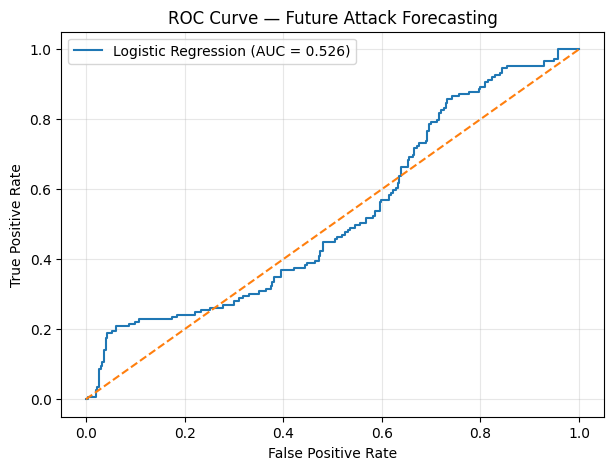

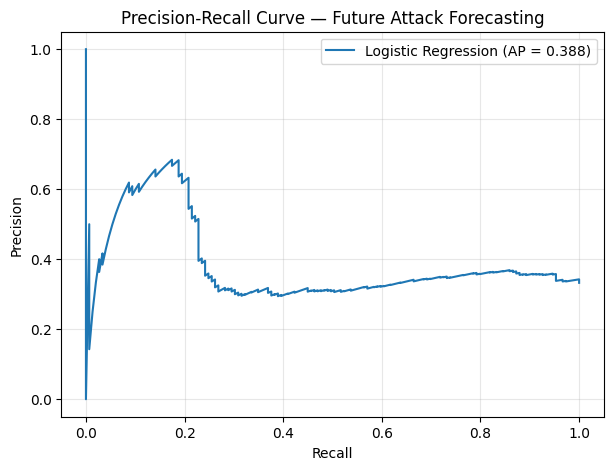

In [79]:
# ============================================================
# STEP 73: ROC + PRECISION-RECALL CURVES
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)


# -------------------------
# ROC CURVE
# -------------------------

fpr, tpr, _ = roc_curve(
    y_val_attack,
    val_attack_prob_logreg
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Future Attack Forecasting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# -------------------------
# PRECISION-RECALL CURVE
# -------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_val_attack,
    val_attack_prob_logreg
)

plt.figure(figsize=(7, 5))

plt.plot(
    pr_recall,
    pr_precision,
    label=f"Logistic Regression (AP = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curve — Future Attack Forecasting"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [80]:
# ============================================================
# STEP 74: THRESHOLD ANALYSIS
# ============================================================

import pandas as pd

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        val_attack_prob_logreg >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_attack,
        predictions,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "Threshold": round(threshold, 2),

        "Precision": precision_score(
            y_val_attack,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val_attack,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_val_attack,
            predictions,
            zero_division=0
        ),

        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })


threshold_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_df.round(4).to_string(index=False)
)

 Threshold  Precision  Recall     F1  False_Positives  False_Negatives  True_Positives  True_Negatives
      0.10     0.2987  0.3087 0.3036              108              103              46             191
      0.15     0.3252  0.2685 0.2941               83              109              40             216
      0.20     0.3486  0.2550 0.2946               71              111              38             228
      0.25     0.3750  0.2416 0.2939               60              113              36             239
      0.30     0.3977  0.2349 0.2954               53              114              35             246
      0.35     0.4096  0.2282 0.2931               49              115              34             250
      0.40     0.4304  0.2282 0.2982               45              115              34             254
      0.45     0.4359  0.2282 0.2996               44              115              34             255
      0.50     0.4658  0.2282 0.3063               39              115   

In [81]:
# ============================================================
# STEP 75: MAJORITY-CLASS BASELINE
# ============================================================

majority_prediction = np.zeros_like(
    y_val_attack
)

majority_accuracy = accuracy_score(
    y_val_attack,
    majority_prediction
)

print(
    "Majority-class validation accuracy:",
    round(majority_accuracy, 4)
)

Majority-class validation accuracy: 0.6674


In [82]:
# ============================================================
# STEP 76: LOGISTIC REGRESSION DIAGNOSTIC CHECK
# ============================================================

import numpy as np

print("=" * 60)
print("LOGISTIC REGRESSION DIAGNOSTICS")
print("=" * 60)

# Number of optimization iterations
print("\nIterations used:")
print(logreg_attack.n_iter_)

# Coefficient statistics
coef = logreg_attack.coef_.ravel()

print("\nCoefficient statistics:")
print(f"Minimum coefficient : {coef.min():.4f}")
print(f"Maximum coefficient : {coef.max():.4f}")
print(f"Mean coefficient    : {coef.mean():.4f}")
print(f"Std coefficient     : {coef.std():.4f}")
print(f"Max absolute coef   : {np.abs(coef).max():.4f}")

# Probability distribution
print("\nValidation probability percentiles:")

percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]

for p in percentiles:
    value = np.percentile(val_attack_prob_logreg, p)
    print(f"{p:>3}% : {value:.6f}")

# Count very confident predictions
print("\nExtreme probability counts:")
print(
    "P < 0.01:",
    np.sum(val_attack_prob_logreg < 0.01)
)

print(
    "P > 0.99:",
    np.sum(val_attack_prob_logreg > 0.99)
)

LOGISTIC REGRESSION DIAGNOSTICS

Iterations used:
[115]

Coefficient statistics:
Minimum coefficient : -1.7282
Maximum coefficient : 1.7915
Mean coefficient    : 0.1170
Std coefficient     : 0.6430
Max absolute coef   : 1.7915

Validation probability percentiles:
  0% : 0.000000
  1% : 0.000000
  5% : 0.000000
 10% : 0.000002
 25% : 0.003579
 50% : 0.040988
 75% : 0.192421
 90% : 0.931779
 95% : 0.999970
 99% : 1.000000
100% : 1.000000

Extreme probability counts:
P < 0.01: 149
P > 0.99: 38


In [88]:
# ============================================================
# DEFINE THE EXACT 23 MODEL INPUT FEATURES
# ============================================================

feature_columns = [
    "Flow_Count",
    "Unique_Source_IPs",
    "Unique_Destination_IPs",
    "Unique_Source_Ports",
    "Unique_Destination_Ports",
    "Flow_Duration_Mean",
    "Flow_Duration_Std",
    "Flow_Duration_Max",
    "Fwd_Packets_Sum",
    "Fwd_Packets_Mean",
    "Bwd_Packets_Sum",
    "Bwd_Packets_Mean",
    "Fwd_Bytes_Sum",
    "Fwd_Bytes_Mean",
    "Bwd_Bytes_Sum",
    "Bwd_Bytes_Mean",
    "Fwd_IAT_Mean",
    "Fwd_IAT_Std",
    "Bwd_IAT_Mean",
    "Bwd_IAT_Std",
    "TCP_Count",
    "UDP_Count",
    "Other_Protocol_Count"
]

print("feature_columns created successfully.")
print("Number of features:", len(feature_columns))

for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2d}. {feature}")

feature_columns created successfully.
Number of features: 23
 1. Flow_Count
 2. Unique_Source_IPs
 3. Unique_Destination_IPs
 4. Unique_Source_Ports
 5. Unique_Destination_Ports
 6. Flow_Duration_Mean
 7. Flow_Duration_Std
 8. Flow_Duration_Max
 9. Fwd_Packets_Sum
10. Fwd_Packets_Mean
11. Bwd_Packets_Sum
12. Bwd_Packets_Mean
13. Fwd_Bytes_Sum
14. Fwd_Bytes_Mean
15. Bwd_Bytes_Sum
16. Bwd_Bytes_Mean
17. Fwd_IAT_Mean
18. Fwd_IAT_Std
19. Bwd_IAT_Mean
20. Bwd_IAT_Std
21. TCP_Count
22. UDP_Count
23. Other_Protocol_Count


In [93]:
# ============================================================
# WITHIN-TRAINING TEMPORAL GENERALIZATION TEST
# Logistic Regression
#
# Fit:      July 3 + July 4
# Evaluate: July 5
#
# IMPORTANT:
# - Does NOT modify the original logreg_attack model
# - Does NOT touch July 6 validation
# - Does NOT touch July 7 test
# - Uses already-scaled X_train sequences
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# STEP 1: Verify alignment
# ------------------------------------------------------------

assert len(train_meta) == len(X_train)
assert len(train_meta) == len(y_train_attack)

print("=" * 70)
print("WITHIN-TRAINING TEMPORAL GENERALIZATION TEST")
print("=" * 70)

print("\nTotal training samples:", len(train_meta))

# ------------------------------------------------------------
# STEP 2: Extract calendar date for every training sample
# ------------------------------------------------------------

train_dates = pd.to_datetime(
    train_meta["Input_Start"]
).dt.date.to_numpy()

unique_dates = np.unique(train_dates)

print("\nTraining dates available:")

for d in unique_dates:
    mask = train_dates == d

    y_day = y_train_attack[mask]

    print(
        d,
        "| Samples:", len(y_day),
        "| Negative:", np.sum(y_day == 0),
        "| Positive:", np.sum(y_day == 1),
        "| Positive %:", round(100 * np.mean(y_day), 2)
    )

# ------------------------------------------------------------
# STEP 3: Define chronological internal split
# ------------------------------------------------------------

# Earlier portion:
# July 3 + July 4
#
# Later portion:
# July 5

internal_train_mask = train_dates < pd.Timestamp(
    "2017-07-05"
).date()

internal_eval_mask = train_dates == pd.Timestamp(
    "2017-07-05"
).date()

X_internal_train = X_train[internal_train_mask]
y_internal_train = y_train_attack[internal_train_mask]

X_internal_eval = X_train[internal_eval_mask]
y_internal_eval = y_train_attack[internal_eval_mask]

print("\n" + "=" * 70)
print("INTERNAL SPLIT")
print("=" * 70)

print(
    "Earlier-period training samples:",
    len(X_internal_train)
)

print(
    "Later-period evaluation samples:",
    len(X_internal_eval)
)

print("\nEarlier training label distribution:")
print(
    dict(
        zip(
            *np.unique(
                y_internal_train,
                return_counts=True
            )
        )
    )
)

print("\nLater evaluation label distribution:")
print(
    dict(
        zip(
            *np.unique(
                y_internal_eval,
                return_counts=True
            )
        )
    )
)

# Safety check:
# Logistic Regression requires both classes in fitting data

assert len(np.unique(y_internal_train)) == 2, (
    "Internal training portion does not contain both classes."
)

assert len(np.unique(y_internal_eval)) == 2, (
    "Internal evaluation portion does not contain both classes."
)

# ------------------------------------------------------------
# STEP 4: Flatten sequences
# ------------------------------------------------------------

# Original sequence:
# (samples, 15 minutes, 23 features)
#
# Logistic Regression requires:
# (samples, 345 features)

X_internal_train_flat = X_internal_train.reshape(
    X_internal_train.shape[0],
    -1
)

X_internal_eval_flat = X_internal_eval.reshape(
    X_internal_eval.shape[0],
    -1
)

print("\nFlattened shapes:")

print(
    "Internal train:",
    X_internal_train_flat.shape
)

print(
    "Internal eval :",
    X_internal_eval_flat.shape
)

# ------------------------------------------------------------
# STEP 5: Train a NEW diagnostic Logistic Regression
# ------------------------------------------------------------

# We create a separate model so the original
# logreg_attack remains untouched.

logreg_temporal = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

logreg_temporal.fit(
    X_internal_train_flat,
    y_internal_train
)

print("\nTraining complete.")

print(
    "Iterations used:",
    logreg_temporal.n_iter_
)

print(
    "Maximum allowed:",
    logreg_temporal.max_iter
)

# ------------------------------------------------------------
# STEP 6: Predictions
# ------------------------------------------------------------

# Training probabilities
train_prob = logreg_temporal.predict_proba(
    X_internal_train_flat
)[:, 1]

# Later-period probabilities
eval_prob = logreg_temporal.predict_proba(
    X_internal_eval_flat
)[:, 1]

# Use standard 0.50 threshold for diagnostic comparison

train_pred = (train_prob >= 0.50).astype(int)
eval_pred = (eval_prob >= 0.50).astype(int)

# ------------------------------------------------------------
# STEP 7: Metric function
# ------------------------------------------------------------

def calculate_metrics(y_true, y_pred, y_prob):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        )
    }

# ------------------------------------------------------------
# STEP 8: Calculate metrics
# ------------------------------------------------------------

internal_train_metrics = calculate_metrics(
    y_internal_train,
    train_pred,
    train_prob
)

internal_eval_metrics = calculate_metrics(
    y_internal_eval,
    eval_pred,
    eval_prob
)

results = pd.DataFrame(
    [
        internal_train_metrics,
        internal_eval_metrics
    ],
    index=[
        "EARLIER_TRAIN",
        "LATER_UNSEEN_DAY"
    ]
)

# ------------------------------------------------------------
# STEP 9: Print results
# ------------------------------------------------------------

print("\n" + "=" * 70)

print(
    "LOGISTIC REGRESSION — WITHIN-TRAINING TEMPORAL TEST"
)

print("=" * 70)

print(
    results.round(4)
)

# ------------------------------------------------------------
# STEP 10: Confusion matrix
# ------------------------------------------------------------

print("\nLater unseen day confusion matrix:")

print(
    confusion_matrix(
        y_internal_eval,
        eval_pred
    )
)

# ------------------------------------------------------------
# STEP 11: Classification report
# ------------------------------------------------------------

print("\nLater unseen day classification report:")

print(
    classification_report(
        y_internal_eval,
        eval_pred,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# STEP 12: Generalization gaps
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERALIZATION GAP")
print("=" * 70)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]:

    train_value = results.loc[
        "EARLIER_TRAIN",
        metric
    ]

    eval_value = results.loc[
        "LATER_UNSEEN_DAY",
        metric
    ]

    difference = train_value - eval_value

    print(
        f"{metric:10s}: "
        f"Train={train_value:.4f} | "
        f"Later={eval_value:.4f} | "
        f"Gap={difference:.4f}"
    )

# ------------------------------------------------------------
# STEP 13: Probability diagnostics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LATER-DAY PROBABILITY DIAGNOSTICS")
print("=" * 70)

percentiles = [
    0,
    1,
    5,
    10,
    25,
    50,
    75,
    90,
    95,
    99,
    100
]

for p in percentiles:

    value = np.percentile(
        eval_prob,
        p
    )

    print(
        f"{p:3d}% : {value:.6f}"
    )

print("\nExtreme probabilities:")

print(
    "P < 0.01:",
    np.sum(eval_prob < 0.01)
)

print(
    "P > 0.99:",
    np.sum(eval_prob > 0.99)
)

WITHIN-TRAINING TEMPORAL GENERALIZATION TEST

Total training samples: 1370

Training dates available:
2017-07-03 | Samples: 449 | Negative: 449 | Positive: 0 | Positive %: 0.0
2017-07-04 | Samples: 450 | Negative: 310 | Positive: 140 | Positive %: 31.11
2017-07-05 | Samples: 471 | Negative: 340 | Positive: 131 | Positive %: 27.81

INTERNAL SPLIT
Earlier-period training samples: 899
Later-period evaluation samples: 471

Earlier training label distribution:
{np.int32(0): np.int64(759), np.int32(1): np.int64(140)}

Later evaluation label distribution:
{np.int32(0): np.int64(340), np.int32(1): np.int64(131)}

Flattened shapes:
Internal train: (899, 345)
Internal eval : (471, 345)

Training complete.
Iterations used: [83]
Maximum allowed: 5000

LOGISTIC REGRESSION — WITHIN-TRAINING TEMPORAL TEST
                  Accuracy  Precision  Recall      F1  ROC_AUC  PR_AUC
EARLIER_TRAIN       0.9633     0.8365  0.9500  0.8896   0.9956  0.9796
LATER_UNSEEN_DAY    0.7792     0.6753  0.3969  0.5000   

In [94]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# RANDOM FOREST — DATA PREPARATION
# ============================================================

# Flatten temporal sequences:
# (samples, 15, 23) -> (samples, 345)

X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_val_rf   = X_val.reshape(X_val.shape[0], -1)

# Targets
y_train_rf = y_train_attack.copy()
y_val_rf   = y_val_attack.copy()


print("=" * 70)
print("RANDOM FOREST DATA PREPARATION")
print("=" * 70)

print("\nInput shapes:")
print("X_train_rf:", X_train_rf.shape)
print("X_val_rf  :", X_val_rf.shape)

print("\nTarget shapes:")
print("y_train_rf:", y_train_rf.shape)
print("y_val_rf  :", y_val_rf.shape)

print("\nExpected features per sample:", 15 * 23)

# Safety checks
assert X_train_rf.shape[0] == len(y_train_rf)
assert X_val_rf.shape[0] == len(y_val_rf)

assert X_train_rf.shape[1] == 15 * 23
assert X_val_rf.shape[1] == 15 * 23

assert np.isnan(X_train_rf).sum() == 0
assert np.isnan(X_val_rf).sum() == 0

assert np.isinf(X_train_rf).sum() == 0
assert np.isinf(X_val_rf).sum() == 0

print("\nTraining label distribution:")
print(np.unique(y_train_rf, return_counts=True))

print("\nValidation label distribution:")
print(np.unique(y_val_rf, return_counts=True))

print("\n✓ All Random Forest input checks passed.")

RANDOM FOREST DATA PREPARATION

Input shapes:
X_train_rf: (1370, 345)
X_val_rf  : (448, 345)

Target shapes:
y_train_rf: (1370,)
y_val_rf  : (448,)

Expected features per sample: 345

Training label distribution:
(array([0, 1], dtype=int32), array([1099,  271]))

Validation label distribution:
(array([0, 1], dtype=int32), array([299, 149]))

✓ All Random Forest input checks passed.


In [95]:
# ============================================================
# RANDOM FOREST — FUTURE ATTACK BASELINE
# ============================================================

rf_model = RandomForestClassifier(

    # Number of decision trees
    n_estimators=500,

    # Allow reasonably complex trees, but prevent unrestricted memorization
    max_depth=15,

    # Require at least 5 samples to split a node
    min_samples_split=5,

    # Require at least 2 samples in a leaf
    min_samples_leaf=2,

    # Consider sqrt(number_of_features) at each split
    max_features="sqrt",

    # Handle class imbalance
    class_weight="balanced",

    # Use bootstrap sampling for individual trees
    bootstrap=True,

    # Use all available CPU cores
    n_jobs=-1,

    # Reproducibility
    random_state=42
)

print("Training Random Forest...")

rf_model.fit(X_train_rf, y_train_rf)

print("✓ Random Forest training complete.")
print("Number of trees:", len(rf_model.estimators_))

Training Random Forest...
✓ Random Forest training complete.
Number of trees: 500


In [96]:
# ============================================================
# RANDOM FOREST — PROBABILITY PREDICTIONS
# ============================================================

rf_train_prob = rf_model.predict_proba(X_train_rf)[:, 1]
rf_val_prob   = rf_model.predict_proba(X_val_rf)[:, 1]

print("=" * 70)
print("RANDOM FOREST PROBABILITY CHECK")
print("=" * 70)

print("\nNumber of training probabilities:", len(rf_train_prob))
print("Number of validation probabilities:", len(rf_val_prob))

print("\nFirst 10 validation probabilities:")
print(np.round(rf_val_prob[:10], 4))

print("\nValidation probability range:")
print("Min:", rf_val_prob.min())
print("Max:", rf_val_prob.max())

assert np.all((rf_val_prob >= 0) & (rf_val_prob <= 1))

print("\n✓ Probability predictions valid.")

RANDOM FOREST PROBABILITY CHECK

Number of training probabilities: 1370
Number of validation probabilities: 448

First 10 validation probabilities:
[0.1197 0.1203 0.083  0.1061 0.0503 0.1039 0.126  0.1937 0.2265 0.2046]

Validation probability range:
Min: 0.005056853294491178
Max: 0.6869415368333707

✓ Probability predictions valid.


In [97]:
# ============================================================
# RANDOM FOREST — VALIDATION EVALUATION
# ============================================================

threshold = 0.50

rf_val_pred = (rf_val_prob >= threshold).astype(int)

rf_accuracy  = accuracy_score(y_val_rf, rf_val_pred)
rf_precision = precision_score(y_val_rf, rf_val_pred, zero_division=0)
rf_recall    = recall_score(y_val_rf, rf_val_pred, zero_division=0)
rf_f1        = f1_score(y_val_rf, rf_val_pred, zero_division=0)
rf_roc_auc   = roc_auc_score(y_val_rf, rf_val_prob)
rf_pr_auc    = average_precision_score(y_val_rf, rf_val_prob)

print("=" * 70)
print("RANDOM FOREST — FUTURE ATTACK")
print("VALIDATION RESULTS")
print("=" * 70)

print(f"\nThreshold : {threshold:.2f}")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")
print(f"PR-AUC    : {rf_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_rf, rf_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_val_rf,
        rf_val_pred,
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST — FUTURE ATTACK
VALIDATION RESULTS

Threshold : 0.50
Accuracy  : 0.6853
Precision : 0.8333
Recall    : 0.0671
F1 Score  : 0.1242
ROC-AUC   : 0.7357
PR-AUC    : 0.5780

Confusion Matrix:
[[297   2]
 [139  10]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6812    0.9933    0.8082       299
           1     0.8333    0.0671    0.1242       149

    accuracy                         0.6853       448
   macro avg     0.7573    0.5302    0.4662       448
weighted avg     0.7318    0.6853    0.5807       448



In [98]:
# ============================================================
# RANDOM FOREST — GENERALIZATION CHECK
# ============================================================

rf_train_pred = (rf_train_prob >= 0.50).astype(int)
rf_val_pred   = (rf_val_prob >= 0.50).astype(int)


def calculate_metrics(y_true, y_pred, y_prob):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        )
    }


rf_train_metrics = calculate_metrics(
    y_train_rf,
    rf_train_pred,
    rf_train_prob
)

rf_val_metrics = calculate_metrics(
    y_val_rf,
    rf_val_pred,
    rf_val_prob
)


rf_generalization = pd.DataFrame(
    [rf_train_metrics, rf_val_metrics],
    index=["TRAIN", "VALIDATION"]
)

print("=" * 70)
print("RANDOM FOREST — GENERALIZATION CHECK")
print("=" * 70)

print(rf_generalization.round(4))

RANDOM FOREST — GENERALIZATION CHECK
            Accuracy  Precision  Recall      F1  ROC_AUC  PR_AUC
TRAIN         1.0000     1.0000  1.0000  1.0000   1.0000   1.000
VALIDATION    0.6853     0.8333  0.0671  0.1242   0.7357   0.578


In [99]:
# ============================================================
# RANDOM FOREST — VALIDATION THRESHOLD ANALYSIS
# ============================================================

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (rf_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_rf,
        pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val_rf,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_rf,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_rf,
        pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })


rf_threshold_df = pd.DataFrame(threshold_results)

print(
    rf_threshold_df.round(4).to_string(index=False)
)

 Threshold  Precision  Recall     F1  False_Positives  False_Negatives  True_Positives  True_Negatives
      0.10     0.4385  0.7651 0.5575              146               35             114             153
      0.15     0.5000  0.7047 0.5850              105               44             105             194
      0.20     0.5673  0.6510 0.6062               74               52              97             225
      0.25     0.6220  0.5302 0.5725               48               70              79             251
      0.30     0.5930  0.3423 0.4340               35               98              51             264
      0.35     0.5625  0.1812 0.2741               21              122              27             278
      0.40     0.6333  0.1275 0.2123               11              130              19             288
      0.45     0.7778  0.0940 0.1677                4              135              14             295
      0.50     0.8333  0.0671 0.1242                2              139   

In [100]:
# ============================================================
# RANDOM FOREST — FEATURE IMPORTANCE
# ============================================================

rf_importances = rf_model.feature_importances_

print("Total flattened feature importances:", len(rf_importances))

assert len(rf_importances) == 15 * len(feature_columns)

# Reshape:
# 345 -> 15 timesteps × 23 features

importance_matrix = rf_importances.reshape(
    15,
    len(feature_columns)
)

# Sum importance across all 15 historical minutes
feature_importance_sum = importance_matrix.sum(axis=0)

rf_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": feature_importance_sum
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("RANDOM FOREST — AGGREGATED FEATURE IMPORTANCE")
print("=" * 70)

print(
    rf_feature_importance.round(6).to_string(index=False)
)

Total flattened feature importances: 345

RANDOM FOREST — AGGREGATED FEATURE IMPORTANCE
                 Feature  Importance
               TCP_Count    0.159794
         Fwd_Packets_Sum    0.081884
Unique_Destination_Ports    0.074548
         Bwd_Packets_Sum    0.072379
              Flow_Count    0.065977
     Unique_Source_Ports    0.050736
           Fwd_Bytes_Sum    0.043102
       Unique_Source_IPs    0.038992
           Bwd_Bytes_Sum    0.037593
      Flow_Duration_Mean    0.037564
  Unique_Destination_IPs    0.036721
            Bwd_IAT_Mean    0.036193
        Bwd_Packets_Mean    0.033921
       Flow_Duration_Std    0.033615
        Fwd_Packets_Mean    0.029067
       Flow_Duration_Max    0.025591
          Bwd_Bytes_Mean    0.024365
          Fwd_Bytes_Mean    0.024041
               UDP_Count    0.023968
            Fwd_IAT_Mean    0.022939
             Bwd_IAT_Std    0.022043
             Fwd_IAT_Std    0.020142
    Other_Protocol_Count    0.004822


In [101]:
# ============================================================
# RANDOM FOREST — TEMPORAL IMPORTANCE
# ============================================================

timestep_importance = importance_matrix.sum(axis=1)

rf_timestep_importance = pd.DataFrame({
    "History_Position": [
        "t-14", "t-13", "t-12", "t-11", "t-10",
        "t-9", "t-8", "t-7", "t-6", "t-5",
        "t-4", "t-3", "t-2", "t-1", "t"
    ],
    "Importance": timestep_importance
})

print("=" * 70)
print("RANDOM FOREST — TEMPORAL IMPORTANCE")
print("=" * 70)

print(
    rf_timestep_importance.round(6).to_string(index=False)
)

print("\nTotal importance:",
      rf_timestep_importance["Importance"].sum())

RANDOM FOREST — TEMPORAL IMPORTANCE
History_Position  Importance
            t-14    0.043781
            t-13    0.048172
            t-12    0.043009
            t-11    0.052546
            t-10    0.054594
             t-9    0.057564
             t-8    0.057849
             t-7    0.056915
             t-6    0.070765
             t-5    0.081834
             t-4    0.085520
             t-3    0.080206
             t-2    0.092509
             t-1    0.090085
               t    0.084651

Total importance: 1.0


In [102]:
# ============================================================
# RANDOM FOREST — PROBABILITY DIAGNOSTICS
# ============================================================

percentiles = [
    0, 1, 5, 10, 25,
    50, 75, 90, 95, 99, 100
]

values = np.percentile(
    rf_val_prob,
    percentiles
)

print("=" * 70)
print("RANDOM FOREST — VALIDATION PROBABILITY DIAGNOSTICS")
print("=" * 70)

for p, value in zip(percentiles, values):
    print(f"{p:>3}% : {value:.6f}")

print("\nExtreme probability counts:")
print("P < 0.01:", np.sum(rf_val_prob < 0.01))
print("P > 0.99:", np.sum(rf_val_prob > 0.99))

RANDOM FOREST — VALIDATION PROBABILITY DIAGNOSTICS
  0% : 0.005057
  1% : 0.009270
  5% : 0.017457
 10% : 0.031217
 25% : 0.056163
 50% : 0.126163
 75% : 0.269545
 90% : 0.355263
 95% : 0.434098
 99% : 0.642466
100% : 0.686942

Extreme probability counts:
P < 0.01: 6
P > 0.99: 0


In [103]:
# ============================================================
# RANDOM FOREST — CONTROLLED HYPERPARAMETER TUNING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. SAFETY CHECKS
# ------------------------------------------------------------

assert X_train_rf.shape[0] == len(y_train_rf)
assert X_val_rf.shape[0] == len(y_val_rf)

assert np.isnan(X_train_rf).sum() == 0
assert np.isnan(X_val_rf).sum() == 0

assert np.isinf(X_train_rf).sum() == 0
assert np.isinf(X_val_rf).sum() == 0

print("Training samples  :", X_train_rf.shape)
print("Validation samples:", X_val_rf.shape)

print("\nTraining labels:")
print(np.unique(y_train_rf, return_counts=True))

print("\nValidation labels:")
print(np.unique(y_val_rf, return_counts=True))


# ------------------------------------------------------------
# 2. CONTROLLED CONFIGURATIONS
# ------------------------------------------------------------
#
# We deliberately vary model complexity.
#
# min_samples_leaf is especially important because your
# previous forest was able to perfectly memorize training data.
#

rf_configs = [

    {
        "name": "RF_A",
        "max_depth": 5,
        "min_samples_leaf": 10,
        "min_samples_split": 20,
        "max_features": "sqrt"
    },

    {
        "name": "RF_B",
        "max_depth": 8,
        "min_samples_leaf": 10,
        "min_samples_split": 20,
        "max_features": "sqrt"
    },

    {
        "name": "RF_C",
        "max_depth": 10,
        "min_samples_leaf": 5,
        "min_samples_split": 10,
        "max_features": "sqrt"
    },

    {
        "name": "RF_D",
        "max_depth": 12,
        "min_samples_leaf": 5,
        "min_samples_split": 10,
        "max_features": "sqrt"
    },

    {
        "name": "RF_E",
        "max_depth": 15,
        "min_samples_leaf": 3,
        "min_samples_split": 6,
        "max_features": "sqrt"
    },

    {
        "name": "RF_F",
        "max_depth": None,
        "min_samples_leaf": 5,
        "min_samples_split": 10,
        "max_features": "sqrt"
    }
]


# ------------------------------------------------------------
# 3. TRAIN AND EVALUATE
# ------------------------------------------------------------

results = []
trained_rf_models = {}

for config in rf_configs:

    print("\n" + "=" * 70)
    print("TRAINING:", config["name"])
    print("=" * 70)

    model = RandomForestClassifier(

        # Enough trees for a stable comparison
        n_estimators=500,

        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        min_samples_split=config["min_samples_split"],
        max_features=config["max_features"],

        # Handle training imbalance
        class_weight="balanced",

        # Reproducibility
        random_state=42,

        # Use all CPU cores
        n_jobs=-1
    )

    model.fit(X_train_rf, y_train_rf)

    # Store model
    trained_rf_models[config["name"]] = model


    # --------------------------------------------------------
    # Probabilities
    # --------------------------------------------------------

    train_prob = model.predict_proba(X_train_rf)[:, 1]
    val_prob = model.predict_proba(X_val_rf)[:, 1]


    # --------------------------------------------------------
    # Default 0.50 predictions
    # --------------------------------------------------------

    train_pred = (train_prob >= 0.50).astype(int)
    val_pred = (val_prob >= 0.50).astype(int)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    result = {

        "Model": config["name"],

        "Max_Depth": str(config["max_depth"]),
        "Min_Leaf": config["min_samples_leaf"],
        "Min_Split": config["min_samples_split"],

        # TRAIN
        "Train_Accuracy":
            accuracy_score(y_train_rf, train_pred),

        "Train_F1":
            f1_score(
                y_train_rf,
                train_pred,
                zero_division=0
            ),

        "Train_ROC_AUC":
            roc_auc_score(
                y_train_rf,
                train_prob
            ),

        "Train_PR_AUC":
            average_precision_score(
                y_train_rf,
                train_prob
            ),

        # VALIDATION
        "Val_Accuracy":
            accuracy_score(y_val_rf, val_pred),

        "Val_Precision":
            precision_score(
                y_val_rf,
                val_pred,
                zero_division=0
            ),

        "Val_Recall":
            recall_score(
                y_val_rf,
                val_pred,
                zero_division=0
            ),

        "Val_F1":
            f1_score(
                y_val_rf,
                val_pred,
                zero_division=0
            ),

        "Val_ROC_AUC":
            roc_auc_score(
                y_val_rf,
                val_prob
            ),

        "Val_PR_AUC":
            average_precision_score(
                y_val_rf,
                val_prob
            )
    }

    results.append(result)

    print(
        f"Train PR-AUC : {result['Train_PR_AUC']:.4f}"
    )

    print(
        f"Val PR-AUC   : {result['Val_PR_AUC']:.4f}"
    )

    print(
        f"Val ROC-AUC  : {result['Val_ROC_AUC']:.4f}"
    )


# ------------------------------------------------------------
# 4. CREATE COMPARISON TABLE
# ------------------------------------------------------------

rf_tuning_results = pd.DataFrame(results)

print("\n")
print("=" * 100)
print("RANDOM FOREST HYPERPARAMETER COMPARISON")
print("=" * 100)

display(
    rf_tuning_results.sort_values(
        "Val_PR_AUC",
        ascending=False
    ).round(4)
)

Training samples  : (1370, 345)
Validation samples: (448, 345)

Training labels:
(array([0, 1], dtype=int32), array([1099,  271]))

Validation labels:
(array([0, 1], dtype=int32), array([299, 149]))

TRAINING: RF_A
Train PR-AUC : 0.8609
Val PR-AUC   : 0.6525
Val ROC-AUC  : 0.7569

TRAINING: RF_B
Train PR-AUC : 0.9610
Val PR-AUC   : 0.6179
Val ROC-AUC  : 0.7467

TRAINING: RF_C
Train PR-AUC : 0.9990
Val PR-AUC   : 0.6009
Val ROC-AUC  : 0.7383

TRAINING: RF_D
Train PR-AUC : 0.9997
Val PR-AUC   : 0.6017
Val ROC-AUC  : 0.7402

TRAINING: RF_E
Train PR-AUC : 1.0000
Val PR-AUC   : 0.5924
Val ROC-AUC  : 0.7355

TRAINING: RF_F
Train PR-AUC : 0.9999
Val PR-AUC   : 0.6037
Val ROC-AUC  : 0.7400


RANDOM FOREST HYPERPARAMETER COMPARISON


,Model,Max_Depth,Min_Leaf,Min_Split,Train_Accuracy,Train_F1,Train_ROC_AUC,Train_PR_AUC,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC,Val_PR_AUC
0,RF_A,5,10,20,0.8620,0.7149,0.9570,0.8609,0.7500,0.7033,0.4295,0.5333,0.7569,0.6525
1,RF_B,8,10,20,0.9423,0.8645,0.9891,0.9610,0.7121,0.6923,0.2416,0.3582,0.7467,0.6179
5,RF_F,None,5,10,0.9971,0.9926,1.0000,0.9999,0.6920,0.7391,0.1141,0.1977,0.7400,0.6037
3,RF_D,12,5,10,0.9971,0.9926,0.9999,0.9997,0.6920,0.7391,0.1141,0.1977,0.7402,0.6017
2,RF_C,10,5,10,0.9905,0.9763,0.9997,0.9990,0.6942,0.7143,0.1342,0.2260,0.7383,0.6009
4,RF_E,15,3,6,1.0000,1.0000,1.0000,1.0000,0.6920,0.8667,0.0872,0.1585,0.7355,0.5924


In [104]:
# ============================================================
# RF_A — VALIDATION THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Retrieve the selected model
# ------------------------------------------------------------

rf_best = trained_rf_models["RF_A"]

print("Selected model: RF_A")
print(rf_best)


# ------------------------------------------------------------
# 2. Generate validation probabilities
# ------------------------------------------------------------

val_prob_rf = rf_best.predict_proba(X_val_rf)[:, 1]

print("\nValidation samples:", len(val_prob_rf))
print("Probability min:", val_prob_rf.min())
print("Probability max:", val_prob_rf.max())


# ------------------------------------------------------------
# 3. Thresholds to investigate
# ------------------------------------------------------------

thresholds = np.arange(0.05, 0.81, 0.05)

threshold_results = []


for threshold in thresholds:

    val_pred = (val_prob_rf >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_rf,
        val_pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val_rf,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_rf,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_rf,
        val_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_val_rf,
        val_pred
    )

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "True_Positives": tp,

        "False_Positives": fp,

        "True_Negatives": tn,

        "False_Negatives": fn
    })


threshold_df = pd.DataFrame(threshold_results)


# ------------------------------------------------------------
# 4. Display complete table
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RF_A — VALIDATION THRESHOLD ANALYSIS")
print("=" * 100)

display(
    threshold_df.round(4)
)


# ------------------------------------------------------------
# 5. Threshold with highest F1
# ------------------------------------------------------------

best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\n" + "=" * 70)
print("BEST THRESHOLD BY VALIDATION F1")
print("=" * 70)

print(best_f1_row.round(4))


# ------------------------------------------------------------
# 6. Highest-recall threshold with precision >= 0.50
# ------------------------------------------------------------

eligible = threshold_df[
    threshold_df["Precision"] >= 0.50
]

if len(eligible) > 0:

    recall_choice = eligible.loc[
        eligible["Recall"].idxmax()
    ]

    print("\n" + "=" * 70)
    print("HIGHEST RECALL WITH PRECISION >= 0.50")
    print("=" * 70)

    print(recall_choice.round(4))

else:

    print(
        "\nNo tested threshold achieved precision >= 0.50"
    )


# ------------------------------------------------------------
# 7. Probability percentiles
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RF_A VALIDATION PROBABILITY DISTRIBUTION")
print("=" * 70)

for percentile in [
    0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100
]:

    value = np.percentile(
        val_prob_rf,
        percentile
    )

    print(
        f"{percentile:>3}% : {value:.6f}"
    )

Selected model: RF_A
RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=500, n_jobs=-1, random_state=42)

Validation samples: 448
Probability min: 0.014497494400183606
Probability max: 0.7517914797194677

RF_A — VALIDATION THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1,True_Positives,False_Positives,True_Negatives,False_Negatives
0,0.05,0.4286,0.3679,1.0000,0.5379,149,256,43,0
1,0.10,0.4754,0.3844,0.9597,0.5489,143,229,70,6
2,0.15,0.5424,0.4108,0.8658,0.5572,129,185,114,20
3,0.20,0.5804,0.4270,0.7651,0.5481,114,153,146,35
4,0.25,0.6451,0.4773,0.7047,0.5691,105,115,184,44
5,0.30,0.6897,0.5253,0.6980,0.5994,104,94,205,45
6,0.35,0.7121,0.5595,0.6309,0.5931,94,74,225,55
7,0.40,0.7455,0.6277,0.5772,0.6014,86,51,248,63
8,0.45,0.7589,0.6783,0.5235,0.5909,78,37,262,71
9,0.50,0.7500,0.7033,0.4295,0.5333,64,27,272,85



BEST THRESHOLD BY VALIDATION F1
Threshold            0.4000
Accuracy             0.7455
Precision            0.6277
Recall               0.5772
F1                   0.6014
True_Positives      86.0000
False_Positives     51.0000
True_Negatives     248.0000
False_Negatives     63.0000
Name: 7, dtype: float64

HIGHEST RECALL WITH PRECISION >= 0.50
Threshold            0.3000
Accuracy             0.6897
Precision            0.5253
Recall               0.6980
F1                   0.5994
True_Positives     104.0000
False_Positives     94.0000
True_Negatives     205.0000
False_Negatives     45.0000
Name: 5, dtype: float64

RF_A VALIDATION PROBABILITY DISTRIBUTION
  0% : 0.014497
  1% : 0.017280
  5% : 0.030320
 10% : 0.051866
 25% : 0.131684
 50% : 0.243901
 75% : 0.456906
 90% : 0.567276
 95% : 0.607160
 99% : 0.724924
100% : 0.751791


In [105]:
import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

# ---------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [108]:
# =========================================================
# RECREATE FUTURE-ATTACK TARGET ARRAYS
# =========================================================

import numpy as np

y_train = train_meta["Future_Attack"].to_numpy(dtype=np.int32)
y_val   = val_meta["Future_Attack"].to_numpy(dtype=np.int32)
y_test  = test_meta["Future_Attack"].to_numpy(dtype=np.int32)

print("=" * 70)
print("FUTURE ATTACK TARGETS RECREATED")
print("=" * 70)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nDistributions:")

for name, y in [
    ("TRAIN", y_train),
    ("VAL", y_val),
    ("TEST", y_test)
]:
    values, counts = np.unique(y, return_counts=True)
    print(f"\n{name}:")
    for value, count in zip(values, counts):
        print(
            f"Label {value}: {count} "
            f"({100 * count / len(y):.2f}%)"
        )

# Critical alignment checks
assert len(y_train) == len(X_train)
assert len(y_val)   == len(X_val)
assert len(y_test)  == len(X_test)

print("\n✓ Target/tensor counts are aligned.")

FUTURE ATTACK TARGETS RECREATED
y_train: (1370,)
y_val  : (448,)
y_test : (446,)

Distributions:

TRAIN:
Label 0: 1099 (80.22%)
Label 1: 271 (19.78%)

VAL:
Label 0: 299 (66.74%)
Label 1: 149 (33.26%)

TEST:
Label 0: 187 (41.93%)
Label 1: 259 (58.07%)

✓ Target/tensor counts are aligned.


In [109]:
# =========================================================
# LSTM INPUT AUDIT
# =========================================================

print("=" * 70)
print("LSTM INPUT AUDIT")
print("=" * 70)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

# Expected dimensions
assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1:] == (15, 23)
assert X_val.shape[1:] == (15, 23)
assert X_test.shape[1:] == (15, 23)

# Sample/target alignment
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# NaN / Inf checks
assert not np.isnan(X_train).any()
assert not np.isnan(X_val).any()
assert not np.isnan(X_test).any()

assert not np.isinf(X_train).any()
assert not np.isinf(X_val).any()
assert not np.isinf(X_test).any()

# Binary target checks
assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_val)).issubset({0, 1})
assert set(np.unique(y_test)).issubset({0, 1})

print("\nTraining labels:")
values, counts = np.unique(y_train, return_counts=True)
for v, c in zip(values, counts):
    print(
        f"Label {v}: {c} "
        f"({100*c/len(y_train):.2f}%)"
    )

print("\nValidation labels:")
values, counts = np.unique(y_val, return_counts=True)
for v, c in zip(values, counts):
    print(
        f"Label {v}: {c} "
        f"({100*c/len(y_val):.2f}%)"
    )

print("\n✓ All LSTM input checks passed.")

LSTM INPUT AUDIT

Shapes:
X_train: (1370, 15, 23)
X_val  : (448, 15, 23)
X_test : (446, 15, 23)

y_train: (1370,)
y_val  : (448,)
y_test : (446,)

Training labels:
Label 0: 1099 (80.22%)
Label 1: 271 (19.78%)

Validation labels:
Label 0: 299 (66.74%)
Label 1: 149 (33.26%)

✓ All LSTM input checks passed.


In [110]:
from sklearn.utils.class_weight import compute_class_weight

# =========================================================
# CLASS WEIGHTS
# =========================================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

print("=" * 70)
print("LSTM CLASS WEIGHTS")
print("=" * 70)

for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.4f}")

LSTM CLASS WEIGHTS
Class 0: 0.6233
Class 1: 2.5277


In [111]:
# =========================================================
# BUILD LSTM
# =========================================================

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

lstm_model = Sequential([

    Input(shape=(15, 23)),

    LSTM(
        units=64,
        return_sequences=False
    ),

    Dropout(0.30),

    Dense(
        units=32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        units=1,
        activation="sigmoid"
    )
])

optimizer = Adam(
    learning_rate=1e-3
)

lstm_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        AUC(
            curve="ROC",
            name="roc_auc"
        ),
        AUC(
            curve="PR",
            name="pr_auc"
        )
    ]
)

print("=" * 70)
print("LSTM MODEL")
print("=" * 70)

lstm_model.summary()

LSTM MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641 (96.25 KB)

 Trainable params: 24,641 (96.25 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
# =========================================================
# CALLBACKS
# =========================================================

early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=20,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

In [113]:
# =========================================================
# TRAIN LSTM
# =========================================================

MAX_EPOCHS = 200
BATCH_SIZE = 32

print("=" * 70)
print("TRAINING LSTM — FUTURE ATTACK")
print("=" * 70)

history_lstm = lstm_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    shuffle=False,
    verbose=1
)

print("\n✓ LSTM training complete.")

epochs_run = len(history_lstm.history["loss"])

print("Maximum epochs allowed:", MAX_EPOCHS)
print("Epochs actually run    :", epochs_run)

TRAINING LSTM — FUTURE ATTACK
Epoch 1/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.7044 - pr_auc: 0.2968 - roc_auc: 0.5152 - val_loss: 0.5404 - val_pr_auc: 0.7631 - val_roc_auc: 0.8112 - learning_rate: 0.0010
Epoch 2/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5851 - pr_auc: 0.5534 - roc_auc: 0.7800 - val_loss: 0.4917 - val_pr_auc: 0.7721 - val_roc_auc: 0.8085 - learning_rate: 0.0010
Epoch 3/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5581 - pr_auc: 0.5220 - roc_auc: 0.7908 - val_loss: 0.4845 - val_pr_auc: 0.7585 - val_roc_auc: 0.8025 - learning_rate: 0.0010
Epoch 4/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5191 - pr_auc: 0.5969 - roc_auc: 0.8193 - val_loss: 0.4854 - val_pr_auc: 0.7451 - val_roc_auc: 0.7967 - learning_rate: 0.0010
Epoch 5/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4968 - pr_auc: 0.6038 - roc_auc: 0.8351 - val_loss: 0.5073 - val_pr_auc: 0.7204 - val_roc_auc: 0.7841 - learning_rate: 0.0010
Epoch 6/200
43/43 ━━━━━━━━━━━━

In [114]:
# =========================================================
# BEST EPOCH
# =========================================================

val_pr_auc_history = np.array(
    history_lstm.history["val_pr_auc"]
)

best_epoch = np.argmax(val_pr_auc_history) + 1
best_val_pr_auc = np.max(val_pr_auc_history)

print("=" * 70)
print("LSTM TRAINING SUMMARY")
print("=" * 70)

print("Epochs actually run :", epochs_run)
print("Best epoch          :", best_epoch)
print(
    "Best validation PR-AUC:",
    round(float(best_val_pr_auc), 4)
)

print(
    "Final stored model uses best weights:",
    True
)

LSTM TRAINING SUMMARY
Epochs actually run : 22
Best epoch          : 2
Best validation PR-AUC: 0.7721
Final stored model uses best weights: True


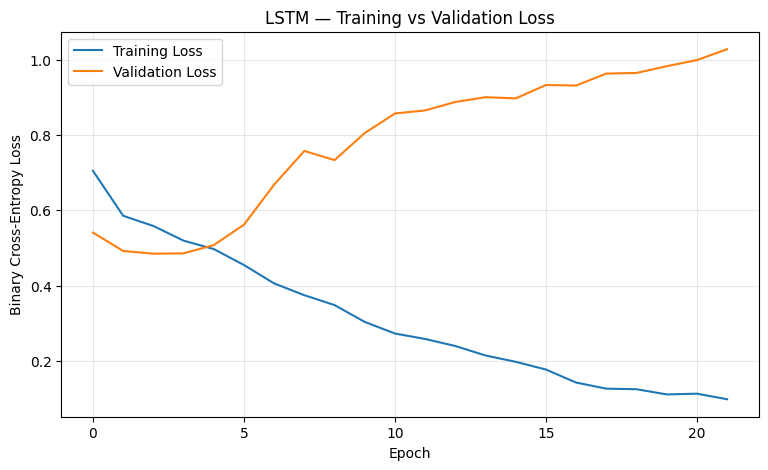

In [115]:
import matplotlib.pyplot as plt

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("LSTM — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

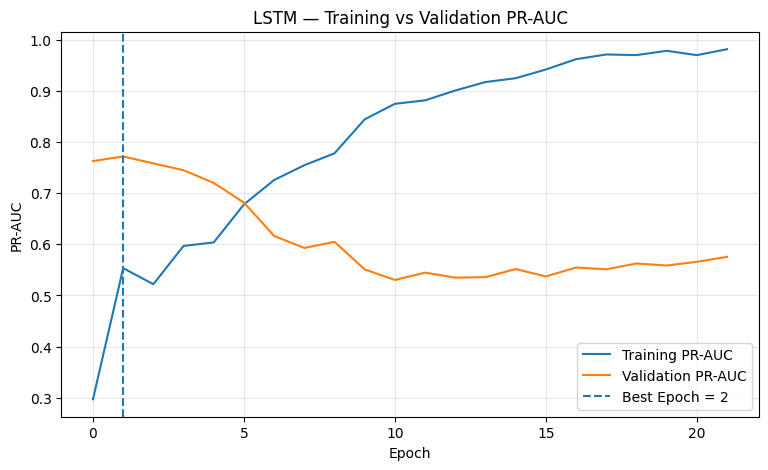

In [116]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["pr_auc"],
    label="Training PR-AUC"
)

plt.plot(
    history_lstm.history["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("LSTM — Training vs Validation PR-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [117]:
# =========================================================
# VALIDATION PREDICTIONS
# =========================================================

val_prob_lstm = lstm_model.predict(
    X_val,
    batch_size=32,
    verbose=0
).ravel()

train_prob_lstm = lstm_model.predict(
    X_train,
    batch_size=32,
    verbose=0
).ravel()

print("=" * 70)
print("LSTM PROBABILITY CHECK")
print("=" * 70)

print("\nValidation predictions:", len(val_prob_lstm))

print(
    "Probability range:",
    float(val_prob_lstm.min()),
    "to",
    float(val_prob_lstm.max())
)

print("\nFirst 10 probabilities:")
print(
    np.round(
        val_prob_lstm[:10],
        4
    )
)

assert len(val_prob_lstm) == len(y_val)
assert np.all(val_prob_lstm >= 0)
assert np.all(val_prob_lstm <= 1)

print("\n✓ Probability predictions valid.")

LSTM PROBABILITY CHECK

Validation predictions: 448
Probability range: 0.09174376726150513 to 0.7976632714271545

First 10 probabilities:
[0.2661 0.3034 0.2949 0.3244 0.3308 0.3873 0.4515 0.486  0.4822 0.4748]

✓ Probability predictions valid.


In [121]:
# ============================================================
# LSTM — VALIDATION EVALUATION + THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 0. SAFETY CHECK — MAKE SURE lstm_model IS REALLY THE LSTM
# ============================================================

import tensorflow as tf

assert isinstance(lstm_model, tf.keras.Model), \
    "lstm_model is not a Keras model!"

assert lstm_model.input_shape == (None, 15, 23), \
    f"Unexpected LSTM input shape: {lstm_model.input_shape}"

assert lstm_model.output_shape == (None, 1), \
    f"Unexpected LSTM output shape: {lstm_model.output_shape}"

print("=" * 70)
print("LSTM MODEL CHECK")
print("=" * 70)
print("Model type :", type(lstm_model))
print("Input shape:", lstm_model.input_shape)
print("Output shape:", lstm_model.output_shape)
print("✓ Correct trained LSTM found.")


# ============================================================
# 1. GET TRAINING AND VALIDATION PROBABILITIES
# ============================================================

train_prob_lstm = lstm_model.predict(
    X_train,
    batch_size=32,
    verbose=0
).ravel()

val_prob_lstm = lstm_model.predict(
    X_val,
    batch_size=32,
    verbose=0
).ravel()


# ============================================================
# 2. PREDICTION SANITY CHECKS
# ============================================================

assert len(train_prob_lstm) == len(y_train), \
    "Training prediction count mismatch."

assert len(val_prob_lstm) == len(y_val), \
    "Validation prediction count mismatch."

assert np.isfinite(train_prob_lstm).all(), \
    "NaN/Inf detected in training probabilities."

assert np.isfinite(val_prob_lstm).all(), \
    "NaN/Inf detected in validation probabilities."

assert np.all(
    (train_prob_lstm >= 0) &
    (train_prob_lstm <= 1)
), "Invalid training probabilities."

assert np.all(
    (val_prob_lstm >= 0) &
    (val_prob_lstm <= 1)
), "Invalid validation probabilities."

print("\n" + "=" * 70)
print("LSTM PROBABILITY CHECK")
print("=" * 70)

print("Training predictions  :", len(train_prob_lstm))
print("Validation predictions:", len(val_prob_lstm))

print(
    "\nTraining probability range:",
    float(train_prob_lstm.min()),
    "to",
    float(train_prob_lstm.max())
)

print(
    "Validation probability range:",
    float(val_prob_lstm.min()),
    "to",
    float(val_prob_lstm.max())
)

print("\n✓ Probability predictions valid.")


# ============================================================
# 3. METRIC FUNCTION
# ============================================================

def calculate_metrics(y_true, probabilities, threshold=0.50):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        )
    }


# ============================================================
# 4. VALIDATION RESULTS AT DEFAULT THRESHOLD = 0.50
# ============================================================

threshold = 0.50

val_pred_lstm = (
    val_prob_lstm >= threshold
).astype(int)

val_metrics_lstm = calculate_metrics(
    y_val,
    val_prob_lstm,
    threshold
)

print("\n" + "=" * 70)
print("LSTM — FUTURE ATTACK")
print("VALIDATION RESULTS")
print("=" * 70)

print(f"\nThreshold : {threshold:.2f}")

for metric, value in val_metrics_lstm.items():
    print(f"{metric:<10}: {value:.4f}")


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_val,
        val_pred_lstm,
        labels=[0, 1]
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_val,
        val_pred_lstm,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 5. TRAIN VS VALIDATION GENERALIZATION
# ============================================================

train_metrics_lstm = calculate_metrics(
    y_train,
    train_prob_lstm,
    threshold
)

generalization_lstm = pd.DataFrame(
    [
        train_metrics_lstm,
        val_metrics_lstm
    ],
    index=[
        "TRAIN",
        "VALIDATION"
    ]
)

print("\n" + "=" * 70)
print("LSTM — GENERALIZATION CHECK")
print("=" * 70)

print(
    generalization_lstm
    .round(4)
    .to_string()
)


# ============================================================
# 6. THRESHOLD SWEEP
# ============================================================

thresholds = np.arange(
    0.05,
    0.81,
    0.05
)

threshold_results = []

for t in thresholds:

    pred = (
        val_prob_lstm >= t
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({

        "Threshold": float(t),

        "Accuracy": accuracy_score(
            y_val,
            pred
        ),

        "Precision": precision_score(
            y_val,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_val,
            pred,
            zero_division=0
        ),

        "True_Positives": int(tp),
        "False_Positives": int(fp),
        "True_Negatives": int(tn),
        "False_Negatives": int(fn)
    })


threshold_df_lstm = pd.DataFrame(
    threshold_results
)

print("\n" + "=" * 100)
print("LSTM — VALIDATION THRESHOLD ANALYSIS")
print("=" * 100)

print(
    threshold_df_lstm
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 7. BEST THRESHOLD BY VALIDATION F1
# ============================================================

best_index = (
    threshold_df_lstm["F1"]
    .idxmax()
)

best_threshold_row_lstm = (
    threshold_df_lstm
    .loc[best_index]
)

best_threshold_lstm = float(
    best_threshold_row_lstm["Threshold"]
)

print("\n" + "=" * 70)
print("BEST THRESHOLD BY VALIDATION F1")
print("=" * 70)

print(
    best_threshold_row_lstm
    .round(4)
    .to_string()
)


# ============================================================
# 8. SECURITY-ORIENTED THRESHOLD
#
# Highest recall while keeping precision >= 0.50
# ============================================================

precision_constraint = threshold_df_lstm[
    threshold_df_lstm["Precision"] >= 0.50
].copy()

print("\n" + "=" * 70)
print("HIGHEST RECALL WITH PRECISION >= 0.50")
print("=" * 70)

if len(precision_constraint) > 0:

    security_row_lstm = (
        precision_constraint
        .sort_values(
            ["Recall", "F1"],
            ascending=False
        )
        .iloc[0]
    )

    security_threshold_lstm = float(
        security_row_lstm["Threshold"]
    )

    print(
        security_row_lstm
        .round(4)
        .to_string()
    )

else:

    security_threshold_lstm = None

    print(
        "No tested threshold satisfies "
        "precision >= 0.50."
    )


# ============================================================
# 9. VALIDATION PROBABILITY DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("LSTM — VALIDATION PROBABILITY DISTRIBUTION")
print("=" * 70)

percentiles = [
    0, 1, 5, 10, 25,
    50, 75, 90, 95, 99, 100
]

for p in percentiles:

    value = np.percentile(
        val_prob_lstm,
        p
    )

    print(
        f"{p:>3}% : {value:.6f}"
    )


print("\nExtreme probability counts:")

print(
    "P < 0.01:",
    int(
        np.sum(
            val_prob_lstm < 0.01
        )
    )
)

print(
    "P > 0.99:",
    int(
        np.sum(
            val_prob_lstm > 0.99
        )
    )
)


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("LSTM VALIDATION EVALUATION COMPLETE")
print("=" * 70)

print(
    f"Best validation-F1 threshold : "
    f"{best_threshold_lstm:.2f}"
)

if security_threshold_lstm is not None:

    print(
        f"Security-oriented threshold  : "
        f"{security_threshold_lstm:.2f}"
    )

print("\nIMPORTANT:")
print("Test set has NOT been used.")
print("Threshold selection is based ONLY on validation data.")

LSTM MODEL CHECK
Model type : <class 'keras.src.models.sequential.Sequential'>
Input shape: (None, 15, 23)
Output shape: (None, 1)
✓ Correct trained LSTM found.

LSTM PROBABILITY CHECK
Training predictions  : 1370
Validation predictions: 448

Training probability range: 0.09861735254526138 to 0.9285165071487427
Validation probability range: 0.09174376726150513 to 0.7976632714271545

✓ Probability predictions valid.

LSTM — FUTURE ATTACK
VALIDATION RESULTS

Threshold : 0.50
Accuracy  : 0.8237
Precision : 0.8125
Recall    : 0.6107
F1        : 0.6973
ROC_AUC   : 0.8085
PR_AUC    : 0.7728

Confusion Matrix:
[[278  21]
 [ 58  91]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8274    0.9298    0.8756       299
           1     0.8125    0.6107    0.6973       149

    accuracy                         0.8237       448
   macro avg     0.8199    0.7703    0.7865       448
weighted avg     0.8224    0.8237    0.8163       448


LSTM — GENERAL

In [122]:
# ============================================================
# LSTM — MULTI-SEED STABILITY TEST
# ============================================================

import numpy as np
import pandas as pd
import random
import tensorflow as tf

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. SAFETY / INPUT CHECKS
# ============================================================

print("=" * 75)
print("MULTI-SEED LSTM STABILITY TEST")
print("=" * 75)

print("\nInput shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

assert X_train.ndim == 3
assert X_val.ndim == 3

assert X_train.shape[1:] == (15, 23)
assert X_val.shape[1:] == (15, 23)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)

assert np.isfinite(X_train).all()
assert np.isfinite(X_val).all()

assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_val)).issubset({0, 1})

print("\n✓ Input checks passed.")
print("✓ Test set will NOT be used.")


# ============================================================
# 2. USE THE SAME CLASS WEIGHTS AS ORIGINAL LSTM
# ============================================================

# Calculate directly from y_train so this cell is self-contained.

negative_count = np.sum(y_train == 0)
positive_count = np.sum(y_train == 1)
total_count = len(y_train)

class_weight_lstm = {
    0: total_count / (2.0 * negative_count),
    1: total_count / (2.0 * positive_count)
}

print("\nClass weights:")
print(f"Class 0: {class_weight_lstm[0]:.4f}")
print(f"Class 1: {class_weight_lstm[1]:.4f}")


# ============================================================
# 3. MODEL BUILDER
# ============================================================
# IMPORTANT:
# This matches the architecture we previously trained:
#
# Input(15, 23)
# -> LSTM(64)
# -> Dropout
# -> Dense(32, relu)
# -> Dropout
# -> Dense(1, sigmoid)
#
# If your original dropout rates were different, replace the
# two values below with the exact rates from the original cell.
# ============================================================

def build_lstm_model(seed):

    # Clear previous TensorFlow graph/model state
    tf.keras.backend.clear_session()

    # Reproducibility
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model_seed = Sequential([
        Input(shape=(15, 23)),

        LSTM(
            64
        ),

        Dropout(
            0.30,
            seed=seed
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            0.30,
            seed=seed + 1
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model_seed.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=[
            tf.keras.metrics.AUC(
                curve="ROC",
                name="roc_auc"
            ),

            tf.keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            )
        ]
    )

    return model_seed


# ============================================================
# 4. SEEDS TO TEST
# ============================================================

seeds = [
    42,
    123,
    456,
    789,
    2026
]

results = []


# ============================================================
# 5. TRAIN SAME MODEL ACROSS ALL SEEDS
# ============================================================

for run_number, seed in enumerate(seeds, start=1):

    print("\n" + "=" * 75)
    print(
        f"RUN {run_number}/{len(seeds)} "
        f"| SEED = {seed}"
    )
    print("=" * 75)

    model_seed = build_lstm_model(seed)


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    early_stopping = EarlyStopping(
        monitor="val_pr_auc",
        mode="max",

        # Same idea as our original training:
        # allow plenty of epochs but stop once validation
        # performance stops improving.
        patience=20,

        restore_best_weights=True,

        verbose=0
    )


    reduce_lr = ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",

        factor=0.5,
        patience=7,

        min_lr=1e-6,

        verbose=0
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history_seed = model_seed.fit(
        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=200,
        batch_size=32,

        class_weight=class_weight_lstm,

        callbacks=[
            early_stopping,
            reduce_lr
        ],

        verbose=0,

        shuffle=True
    )


    # --------------------------------------------------------
    # Number of epochs actually trained
    # --------------------------------------------------------

    epochs_run = len(
        history_seed.history["loss"]
    )


    # --------------------------------------------------------
    # Best epoch according to validation PR-AUC
    # --------------------------------------------------------

    validation_pr_history = np.array(
        history_seed.history["val_pr_auc"]
    )

    best_epoch = (
        np.argmax(validation_pr_history) + 1
    )

    best_recorded_val_pr_auc = (
        validation_pr_history[
            best_epoch - 1
        ]
    )


    # --------------------------------------------------------
    # Predictions using restored BEST weights
    # --------------------------------------------------------

    train_prob_seed = model_seed.predict(
        X_train,
        batch_size=32,
        verbose=0
    ).ravel()

    val_prob_seed = model_seed.predict(
        X_val,
        batch_size=32,
        verbose=0
    ).ravel()


    # Probability safety checks
    assert np.isfinite(
        train_prob_seed
    ).all()

    assert np.isfinite(
        val_prob_seed
    ).all()

    assert np.all(
        (train_prob_seed >= 0) &
        (train_prob_seed <= 1)
    )

    assert np.all(
        (val_prob_seed >= 0) &
        (val_prob_seed <= 1)
    )


    # --------------------------------------------------------
    # Threshold-independent metrics
    # --------------------------------------------------------

    train_roc = roc_auc_score(
        y_train,
        train_prob_seed
    )

    train_pr = average_precision_score(
        y_train,
        train_prob_seed
    )

    val_roc = roc_auc_score(
        y_val,
        val_prob_seed
    )

    val_pr = average_precision_score(
        y_val,
        val_prob_seed
    )


    # --------------------------------------------------------
    # Threshold = 0.50 metrics
    #
    # We use 0.50 here ONLY for stability comparison.
    # We are NOT choosing the final threshold here.
    # --------------------------------------------------------

    val_pred_seed = (
        val_prob_seed >= 0.50
    ).astype(int)

    val_accuracy = accuracy_score(
        y_val,
        val_pred_seed
    )

    val_precision = precision_score(
        y_val,
        val_pred_seed,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_pred_seed,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_pred_seed,
        zero_division=0
    )


    # --------------------------------------------------------
    # Save run results
    # --------------------------------------------------------

    results.append({

        "Seed": seed,

        "Epochs_Run":
            epochs_run,

        "Best_Epoch":
            best_epoch,

        "Best_Keras_Val_PR_AUC":
            best_recorded_val_pr_auc,

        "Train_ROC_AUC":
            train_roc,

        "Train_PR_AUC":
            train_pr,

        "Val_ROC_AUC":
            val_roc,

        "Val_PR_AUC":
            val_pr,

        "Val_Accuracy_0.5":
            val_accuracy,

        "Val_Precision_0.5":
            val_precision,

        "Val_Recall_0.5":
            val_recall,

        "Val_F1_0.5":
            val_f1
    })


    print(
        f"Epochs run     : {epochs_run}"
    )

    print(
        f"Best epoch     : {best_epoch}"
    )

    print(
        f"Train ROC-AUC  : {train_roc:.4f}"
    )

    print(
        f"Train PR-AUC   : {train_pr:.4f}"
    )

    print(
        f"Val ROC-AUC    : {val_roc:.4f}"
    )

    print(
        f"Val PR-AUC     : {val_pr:.4f}"
    )

    print(
        f"Val F1 @ 0.50  : {val_f1:.4f}"
    )


# ============================================================
# 6. RESULTS TABLE
# ============================================================

stability_results = pd.DataFrame(
    results
)

print("\n\n" + "=" * 110)
print("LSTM — MULTI-SEED RESULTS")
print("=" * 110)

print(
    stability_results
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 7. SUMMARY STATISTICS
# ============================================================

metrics_to_summarize = [
    "Best_Epoch",
    "Train_ROC_AUC",
    "Train_PR_AUC",
    "Val_ROC_AUC",
    "Val_PR_AUC",
    "Val_Accuracy_0.5",
    "Val_Precision_0.5",
    "Val_Recall_0.5",
    "Val_F1_0.5"
]

summary_rows = []

for metric in metrics_to_summarize:

    values = stability_results[
        metric
    ].astype(float)

    summary_rows.append({

        "Metric":
            metric,

        "Mean":
            values.mean(),

        "Std":
            values.std(ddof=1),

        "Min":
            values.min(),

        "Max":
            values.max()
    })


stability_summary = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 110)
print("STABILITY SUMMARY")
print("=" * 110)

print(
    stability_summary
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. GENERALIZATION GAP ACROSS SEEDS
# ============================================================

stability_results[
    "ROC_Gap"
] = (
    stability_results["Train_ROC_AUC"]
    -
    stability_results["Val_ROC_AUC"]
)

stability_results[
    "PR_Gap"
] = (
    stability_results["Train_PR_AUC"]
    -
    stability_results["Val_PR_AUC"]
)


print("\n" + "=" * 110)
print("TRAIN → VALIDATION GENERALIZATION GAPS")
print("=" * 110)

print(
    stability_results[
        [
            "Seed",
            "Best_Epoch",
            "Train_ROC_AUC",
            "Val_ROC_AUC",
            "ROC_Gap",
            "Train_PR_AUC",
            "Val_PR_AUC",
            "PR_Gap"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 9. KEY STABILITY NUMBERS
# ============================================================

mean_val_roc = stability_results[
    "Val_ROC_AUC"
].mean()

std_val_roc = stability_results[
    "Val_ROC_AUC"
].std(ddof=1)

mean_val_pr = stability_results[
    "Val_PR_AUC"
].mean()

std_val_pr = stability_results[
    "Val_PR_AUC"
].std(ddof=1)

mean_val_f1 = stability_results[
    "Val_F1_0.5"
].mean()

std_val_f1 = stability_results[
    "Val_F1_0.5"
].std(ddof=1)


print("\n" + "=" * 75)
print("FINAL MULTI-SEED STABILITY NUMBERS")
print("=" * 75)

print(
    f"Validation ROC-AUC : "
    f"{mean_val_roc:.4f} ± {std_val_roc:.4f}"
)

print(
    f"Validation PR-AUC  : "
    f"{mean_val_pr:.4f} ± {std_val_pr:.4f}"
)

print(
    f"Validation F1@0.50 : "
    f"{mean_val_f1:.4f} ± {std_val_f1:.4f}"
)

print("\nBest epochs:")
print(
    stability_results[
        ["Seed", "Best_Epoch", "Epochs_Run"]
    ].to_string(index=False)
)

print("\n✓ Stability experiment complete.")
print("✓ X_test / y_test were NOT used.")
print("✓ Original lstm_model was NOT overwritten.")

MULTI-SEED LSTM STABILITY TEST

Input shapes:
X_train: (1370, 15, 23)
X_val  : (448, 15, 23)
y_train: (1370,)
y_val  : (448,)

✓ Input checks passed.
✓ Test set will NOT be used.

Class weights:
Class 0: 0.6233
Class 1: 2.5277

RUN 1/5 | SEED = 42
Epochs run     : 21
Best epoch     : 1
Train ROC-AUC  : 0.8389
Train PR-AUC   : 0.6204
Val ROC-AUC    : 0.8014
Val PR-AUC     : 0.7593
Val F1 @ 0.50  : 0.6969

RUN 2/5 | SEED = 123
Epochs run     : 21
Best epoch     : 1
Train ROC-AUC  : 0.8440
Train PR-AUC   : 0.6302
Val ROC-AUC    : 0.8050
Val PR-AUC     : 0.7817
Val F1 @ 0.50  : 0.7260

RUN 3/5 | SEED = 456
Epochs run     : 21
Best epoch     : 1
Train ROC-AUC  : 0.8529
Train PR-AUC   : 0.6262
Val ROC-AUC    : 0.7873
Val PR-AUC     : 0.7454
Val F1 @ 0.50  : 0.6620

RUN 4/5 | SEED = 789
Epochs run     : 21
Best epoch     : 1
Train ROC-AUC  : 0.8455
Train PR-AUC   : 0.6369
Val ROC-AUC    : 0.7878
Val PR-AUC     : 0.7567
Val F1 @ 0.50  : 0.6937

RUN 5/5 | SEED = 2026
Epochs run     : 21
Best ep